## 1-1 선 그래프

### 기본 사용 방법

- `matplotlib.pyplot` 을 `plt`로 임포트한다

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기

import pandas as pd

import matplotlib.pyplot as plt



# 1. 파일 업로드 (실행 시 '파일 선택' 버튼이 나타난)

from google.colab import files

uploaded = files.upload()



# 2. Excel 데이터를 데이터프레임으로 변환

# fillna(0)

df = pd.read_excel('시도별_전출입_인구수.xlsx', header=0)

df.head()

Saving 시도별_전출입_인구수.xlsx to 시도별_전출입_인구수.xlsx


,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8808256,8487275,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226
2,NaN,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,2025358,1873188,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937
3,NaN,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,514502,519310,519334,508043,461042,478451,485710,507031,459015,439073
4,NaN,대구광역시,-,-,-,-,-,-,-,-,...,409938,398626,370817,370563,348642,351873,350213,351424,328228,321182


- `mask` : 원하는 행만 골라낸다
    - `mask = (조건1) & (조건2)`: 전출지가 서울이고 동시에 전입지는 서울이 아닌 행이면 True인 불리언 시리즈를 만든다
        - `&`를 쓸 때는 조건마다 괄호가 필수
    
    | 뜻 | 기호 | 예시 |
    | --- | --- | --- |
    | 그리고 (AND) | `&` | 둘 다 참 |
    | 또는 (OR) | `|` | 하나라도 참 |
    | 아니다 (NOT) | `~` | `~mask` → True/False 뒤집기 |

In [ ]:
# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
# method: 어떤 방식으로 채울지 정하는 옵
df = df.fillna(method='ffill')

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
# True인 행만 남기기
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)
df.head()

/tmp/ipykernel_759/759162571.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8808256,8487275,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226
2,전국,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,2025358,1873188,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937
3,전국,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,514502,519310,519334,508043,461042,478451,485710,507031,459015,439073
4,전국,대구광역시,-,-,-,-,-,-,-,-,...,409938,398626,370817,370563,348642,351873,350213,351424,328228,321182


In [ ]:
# 서울에서 경기도로 이동한 인구 데이터 값만 선택
sr_one = df_seoul.loc['경기도']
sr_one.head()

,경기도
1970,130149
1971,150313
1972,93333
1973,143234
1974,149045


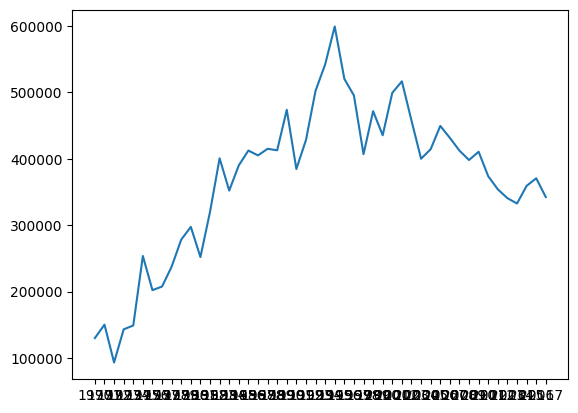

In [ ]:
# x, y축 데이터를 plot 함수에 입력
plt.plot(sr_one.index, sr_one.values)

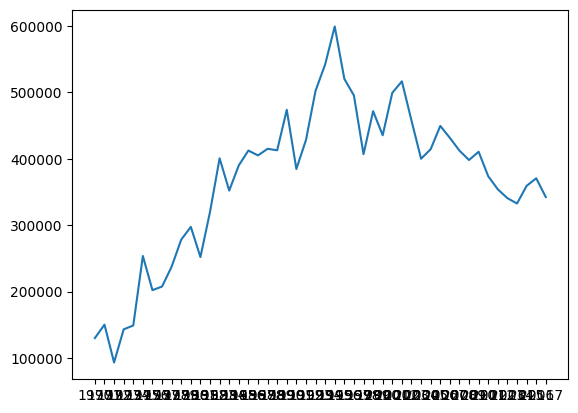

In [ ]:
# 판다스 객체를 plot 함수에 입력
plt.plot(sr_one)

### 차트 제목, 축 이름 추가

- `plt.title()` : 차트 제목 붙이기
    - `plt.xlabel()` / `plt.ylabel()`: x축과 y축 이름을 붙이기
- `plt.show()` : 지금까지 설정한 내용을 반영해 그래프를 화면에 출력

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

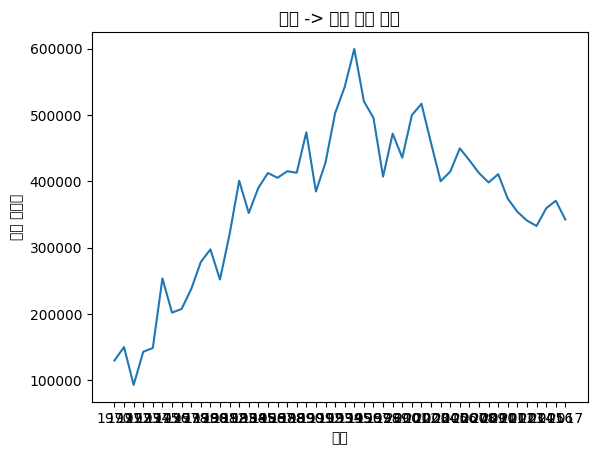

In [ ]:
# 서울에서 경기도로 이동한 인구 데이터 값만 선택
sr_one = df_seoul.loc['경기도']

# x, y축 데이터를 plot 함수에 입력
plt.plot(sr_one.index, sr_one.values)

# 차트 제목 추가
plt.title('서울 -> 경기 인구 이동')

# 축 이름 추가
plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.show()  # 변경사항 저장하고 그래프 출력

### Matplotlib 한글 폰트 오류 해결

- `font_manager` : matplotlib이 사용할 수 있는 폰트 목록을 관리하는 객체
- `FontProperties` : `font_manager` 모듈에 들어 있는 클래스, 글꼴의 속성을 담는 객체를 만든다
    - `fname=` 인자에 폰트 파일 경로를 넣으면, 그 파일을 사용하는 FontProperties 객체가 만들어진다
- `.get_name()` : FontProperties 객체의 메소드로, 폰트 파일 내부에 저장된 폰트 이름을 문자열로 반환
- `rc('font', family=font_name)` :matplotlib의 함수, rcParams의 값을 바꾼다

Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


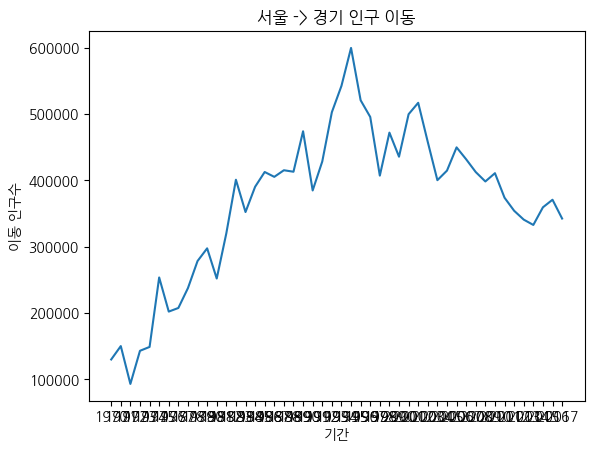

In [ ]:
# -*- coding: utf-8 -*-
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

# matplotlib 한글 폰트 오류 문제 해결
# !는 이 줄을 파이썬 코드가 아니라 리눅스 명령어로 실행하라는 코랩(IPython) 문법
#-qq는 설치 과정의 출력을 최소로 줄이는 옵션, -y는 설치 확인 질문에 자동으로 "yes"라고 답하는 옵션
!apt-get -qq install -y fonts-nanum                                  # [추가] 나눔 폰트 설치
from matplotlib import font_manager, rc
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"         # [수정] 폰트 파일 위치
font_manager.fontManager.addfont(font_path)                           # [추가] matplotlib에 폰트 등록
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 2. Excel 데이터를 데이터프레임으로 변환
# fillna(0)
df = pd.read_excel('시도별_전출입_인구수.xlsx', header=0)

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
# method: 어떤 방식으로 채울지 정하는 옵션
df = df.ffill()                                                       # [수정] fillna(method='ffill')와 같은 기능

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
# True인 행만 남기기
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 서울에서 경기도로 이동한 인구 데이터 값만 선택
sr_one = df_seoul.loc['경기도']

# x, y축 데이터를 plot 함수에 입력
plt.plot(sr_one.index, sr_one.values)

# 차트 제목 추가
plt.title('서울 -> 경기 인구 이동')

# 축 이름 추가
plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.show()

### 그래프 꾸미기

- `plt.figure()` : 새로운 Figure 객체를 만들고 그것을 현재 Figure로 지정하는 함수
- `plt.xticks()` : 현재 Axes(실제로 그래프가 그려지는 영역)의 x축 눈금의 위치와 라벨을 조회하거나 설정하는 함수
- `plt.style.use(style)` : 스타일 시트를 적용하는 함수
- `plt.plot(x, y, 선의 속성)` : 현재 Axes에 Line2D 객체(선 그래프를 이루는 선)를 그리는 함수
    - `marker`: 각 데이터 점의 위치에 표시할 기호의 모양
        - `'o'` : 원
        - `'s'` : 사각형
        - `'^'` : 삼각형
        - `'*'` : 별
        - `'+'` : 십자
    - `markersize` : 마커의 크기, 단위는 포인트(pt)
- `plt.legend(**kwargs)` : 현재 Axes에 범례(legend)를 추가하는 함수
    - `labels`: 범례에 표시할 이름의 리스트, 그래프를 **그**린 순서대로 선과 하나씩 짝지어진다
    - `loc`: 범례의 위치
        - `‘best’`:그래프 요소와 가장 적게 겹치는 위치를 자동으로 계산하는 값

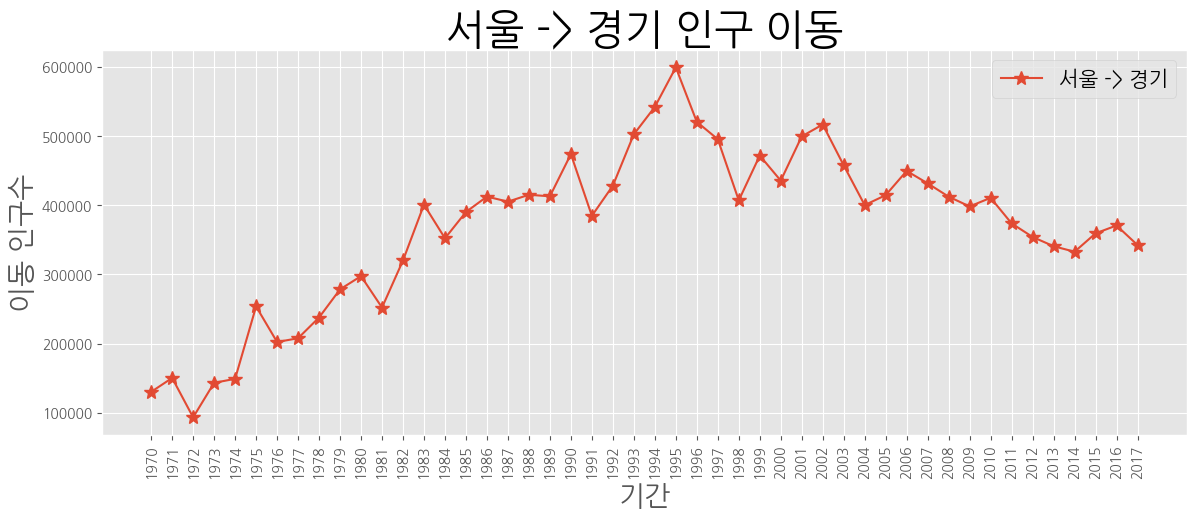

In [ ]:
# 서울에서 경기도로 이동한 인구 데이터 값만 선택
sr_one = df_seoul.loc['경기도']

# 스타일 서식 지정
plt.style.use('ggplot')

# 그림 사이즈 지정
plt.figure(figsize=(14, 5))

# x축 눈금 라벨 회전하기
plt.xticks(size=10, rotation='vertical')

# x, y축 데이터를 plot 함수에 입력
plt.plot(sr_one.index, sr_one.values, marker='*', markersize=10)   # 마커 표시 추가

plt.title('서울 -> 경기 인구 이동', size=30)   # 차트 제목
plt.xlabel('기간', size=20)                   # x축 이름
plt.ylabel('이동 인구수', size=20)             # y축 이름

plt.legend(labels=['서울 -> 경기'], loc='best', fontsize=15)   # 범례 표시

plt.show()  # 변경사항 저장하고 그래프 출력

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import matplotlib.pyplot as plt

# 스타일 리스트 출력
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


### 주석 달기 `annotate()`

#### `plt.ylim(bottom, top)`

- 현재 Axes의 y축 표시 범위를 정하는 함수
- 인자 없이 호출하면 지금 범위를 `(bottom, top)` 튜플로 돌려준다

#### `plt.annotate(text, xy, xytext=None, xycoords='data', arrowprops=None, **kwargs)`

- 그래프의 한 점 `xy`에 텍스트 `text`를 붙이는 함수, `Annotation` 객체를 반환
인자	정의


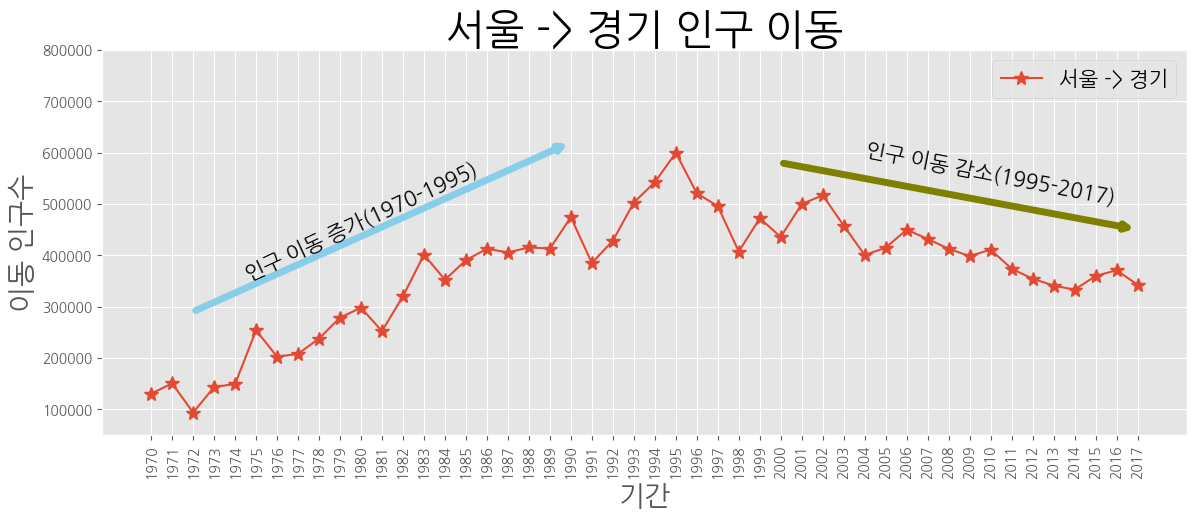

In [ ]:
# 서울에서 경기도로 이동한 인구 데이터 값만 선택
sr_one = df_seoul.loc['경기도']

# 스타일 서식 지정
plt.style.use('ggplot')

# 그림 사이즈 지정
plt.figure(figsize=(14, 5))

# x축 눈금 라벨 회전하기
plt.xticks(size=10, rotation='vertical')

# x, y축 데이터를 plot 함수에 입력
plt.plot(sr_one.index, sr_one.values, marker='*', markersize=10)   # 마커 표시 추가

plt.title('서울 -> 경기 인구 이동', size=30)   # 차트 제목
plt.xlabel('기간', size=20)                   # x축 이름
plt.ylabel('이동 인구수', size=20)             # y축 이름

plt.legend(labels=['서울 -> 경기'], loc='best', fontsize=15)   # 범례 표시

# y축 범위 지정(최소값, 최대값)
plt.ylim(50000, 800000)

# 주석 표시 - 화살표
plt.annotate('',
             xy=(20, 620000),       # 화살표의 머리 부분(끝점)
             xytext=(2, 290000),    # 화살표의 꼬리 부분(시작점)
             xycoords='data',       # 좌표체계
             arrowprops=dict(arrowstyle='->', color='skyblue', lw=5),  # 화살표 서식
             )

plt.annotate('',
             xy=(47, 450000),       # 화살표의 머리 부분(끝점)
             xytext=(30, 580000),   # 화살표의 꼬리 부분(시작점)
             xycoords='data',       # 좌표체계
             arrowprops=dict(arrowstyle='->', color='olive', lw=5),  # 화살표 서식
             )

# 주석 표시 - 텍스트
plt.annotate('인구 이동 증가(1970-1995)',  # 텍스트 입력
             xy=(10, 350000),              # 텍스트 위치 기준점
             rotation=25,                  # 텍스트 회전 각도
             va='baseline',                # 텍스트 상하 정렬
             ha='center',                  # 텍스트 좌우 정렬
             fontsize=15,                  # 텍스트 크기
             )

plt.annotate('인구 이동 감소(1995-2017)',
             xy=(40, 500000),
             rotation=-11,
             va='baseline',
             ha='center',
             fontsize=15,
             )

plt.show()  # 변경사항 저장하고 그래프 출력

### 화면 분할해 그래프 여러 개 그리기 - axe 객체 활용

- figure 객체: 그래프 전체를 담는 최상위 그림 틀
    - `plt.figure()`
- axes 객체: Figure 안에서 x축·y축 좌표계를 가진 개별 그래프 영역
- `plt.figure(figsize=(가로, 세로))` : 새 figure 객체 생성해 반환
- `fig.add_subplot(nrows, ncols, index)` : figure를 `nrows`행 × `ncols`열 격자로 나눈 뒤, `index`번째 칸에 Axes를 만들어 반환
    - `index`는 1부터 시작, 왼쪽 →오른쪽, 위 →아래 순

#### Axes 메소드
| 메소드 | 정의 |
| --- | --- |
| `ax.plot(x, y, 포맷문자열, **kwargs)` |   해당 Axes에 선 그래프를 그림, Series 하나만 주면 index를 x, values를 y로 사용 |
| `ax.legend(loc='best')` |   • `label`로 지정한 이름으로 범례를 표시 |
| `ax.set_ylim(최소, 최대)` |   • 해당 Axes의 y축 범위를 설정 |
| `ax.set_xticklabels(labels, rotation=각도)` |   • x축 눈금 라벨의 글자와 회전 각도를 설정 |

/tmp/ipykernel_759/1789272847.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(sr_one.index, rotation=75)
/tmp/ipykernel_759/1789272847.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(sr_one.index, rotation=75)


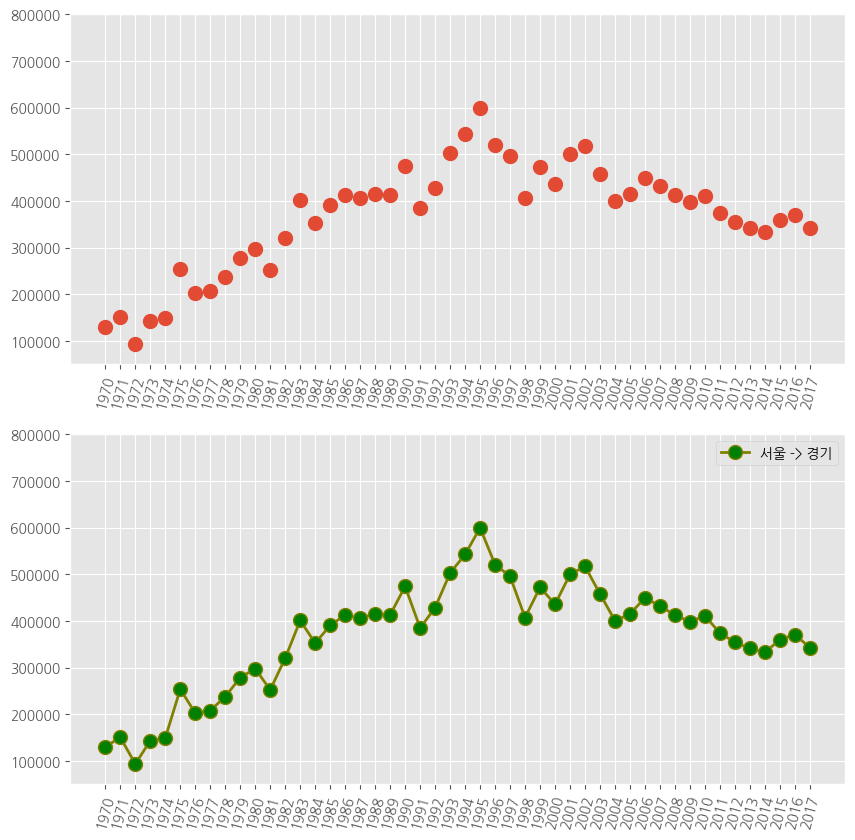

In [ ]:
# 그래프 객체 생성(figure에 2개의 서브 플롯 생성)
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)

# axe 객체에 plot 함수로 그래프 출력
# 'o': 점 그래프로 표현됨
ax1.plot(sr_one, 'o', markersize=10)
ax2.plot(sr_one, marker='o', markerfacecolor='green', markersize=10,
         color='olive', linewidth=2, label='서울 -> 경기')
ax2.legend(loc='best')

# y축 범위 지정(최소값, 최대값)
ax1.set_ylim(50000, 800000)
ax2.set_ylim(50000, 800000)

# 축 눈금 라벨 지정 및 75도 회전
ax1.set_xticklabels(sr_one.index, rotation=75)
ax2.set_xticklabels(sr_one.index, rotation=75)

plt.show()  # 변경사항 저장하고 그래프 출력

/tmp/ipykernel_759/920469757.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sr_one.index, rotation=75)


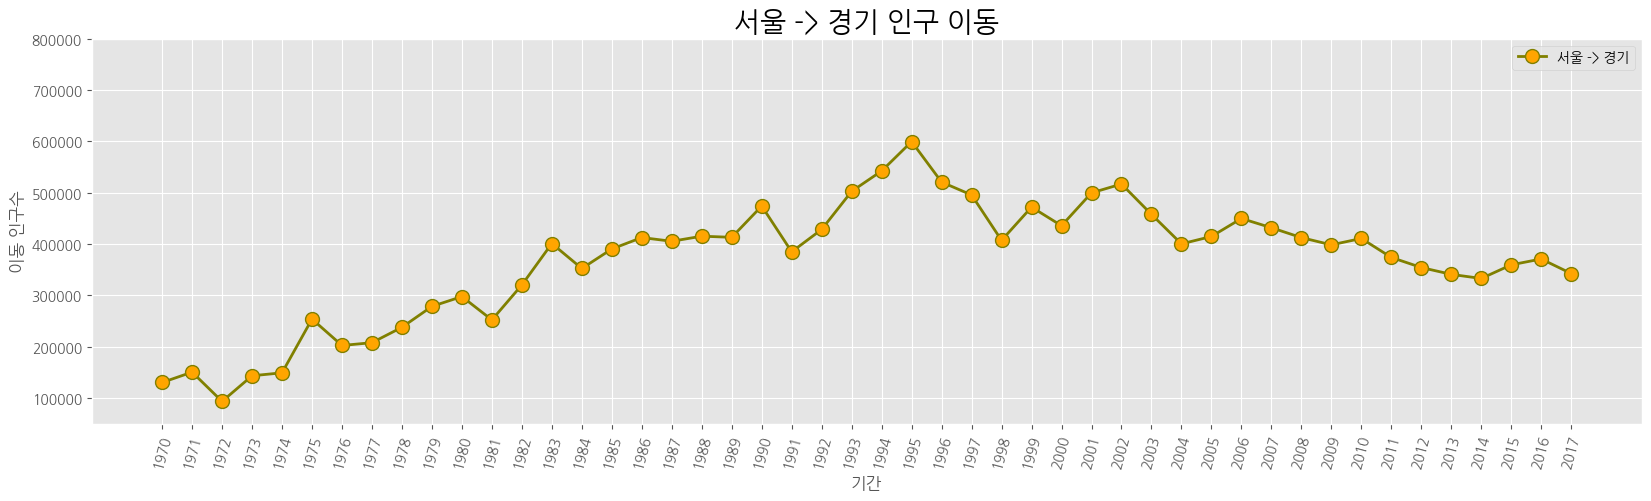

In [ ]:
# 그래프 객체 생성(figure에 1개의 서브 플롯 생성)
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(1, 1, 1)

# axe 객체에 plot 함수로 그래프 출력
ax.plot(sr_one, marker='o', markerfacecolor='orange', markersize=10,
        color='olive', linewidth=2, label='서울 -> 경기')
ax.legend(loc='best')

# y축 범위 지정(최소값, 최대값)
ax.set_ylim(50000, 800000)

# 차트 제목 추가
ax.set_title('서울 -> 경기 인구 이동', size=20)

# 축 이름 추가
ax.set_xlabel('기간', size=12)
ax.set_ylabel('이동 인구수', size=12)

# 축 눈금 라벨 지정 및 75도 회전
ax.set_xticklabels(sr_one.index, rotation=75)

# 축 눈금 라벨 크기
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.show()  # 변경사항 저장하고 그래프 출력

#### 같은 화면에 그래프 여러 개 추가

- 같은 Axes에 ****`plot()`을 여러 번 호출하면 선이 한 좌표평면에 겹쳐 그려짐
- `map(함수, 반복가능객체)` : 반복가능객체의 각 원소에 함수를 적용한 결과를 차례로 내주는 map 객체를 반환

/tmp/ipykernel_759/3356347085.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(col_years, rotation=90)


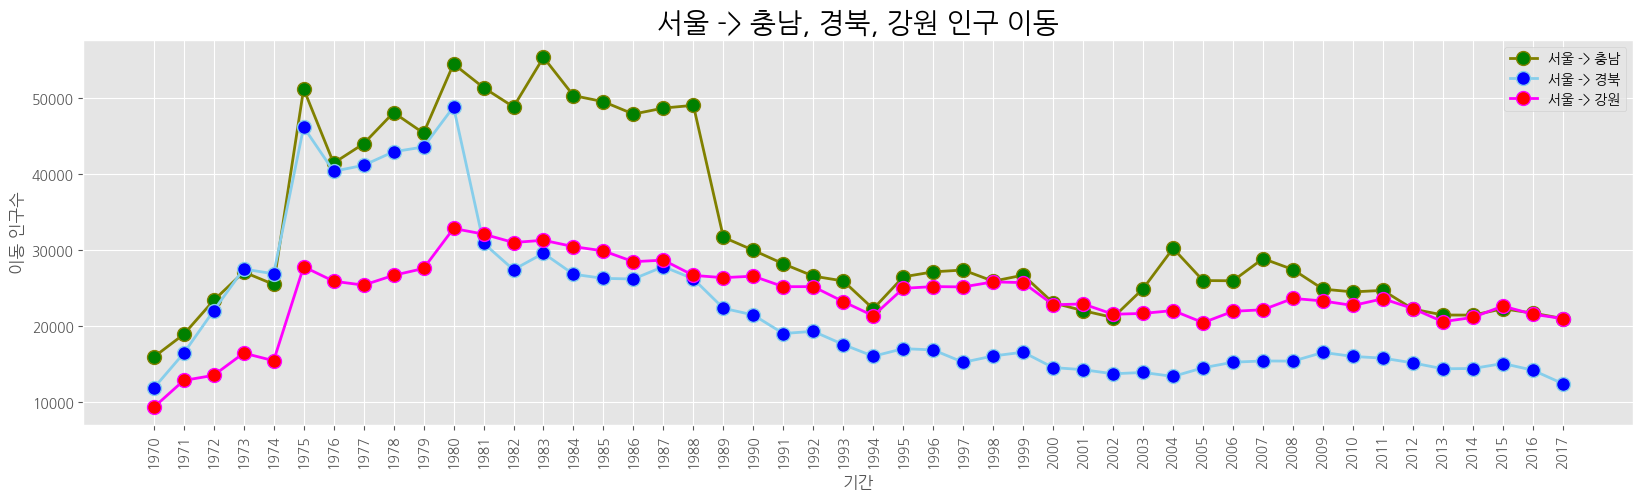

In [ ]:
# 서울에서 '충청남도', '경상북도', '강원도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(1970, 2018)))
# 전입지가 세 지역인 행과, 1970~2017년 열만 고른다
df_3 = df_seoul.loc[['충청남도', '경상북도', '강원도'], col_years]

# 스타일 서식 지정
plt.style.use('ggplot')

# 그래프 객체 생성(figure에 1개의 서브 플롯 생성)
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(1, 1, 1)

# axe 객체에 plot 함수로 그래프 출력
ax.plot(col_years, df_3.loc['충청남도', :], marker='o', markerfacecolor='green',
        markersize=10, color='olive', linewidth=2, label='서울 -> 충남')
ax.plot(col_years, df_3.loc['경상북도', :], marker='o', markerfacecolor='blue',
        markersize=10, color='skyblue', linewidth=2, label='서울 -> 경북')
ax.plot(col_years, df_3.loc['강원도', :], marker='o', markerfacecolor='red',
        markersize=10, color='magenta', linewidth=2, label='서울 -> 강원')

# 범례 표시
ax.legend(loc='best')

# 차트 제목 추가
ax.set_title('서울 -> 충남, 경북, 강원 인구 이동', size=20)

# 축 이름 추가
ax.set_xlabel('기간', size=12)
ax.set_ylabel('이동 인구수', size=12)

# 축 눈금 라벨 지정 및 90도 회전
ax.set_xticklabels(col_years, rotation=90)

# 축 눈금 라벨 크기
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.show()  # 변경사항 저장하고 그래프 출력

#### 화면 분할 그래프

`fig.add_subplot(nrows, ncols, index)`

- Figure 객체의 메소드
- Figure를 `nrows`행 × `ncols`열로 나눈 격자에 `index`번째 칸에 Axes 만들어 반환

/tmp/ipykernel_759/1593044986.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(col_years, rotation=90)
/tmp/ipykernel_759/1593044986.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(col_years, rotation=90)
/tmp/ipykernel_759/1593044986.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(col_years, rotation=90)
/tmp/ipykernel_759/1593044986.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(col_years, rotation=90)


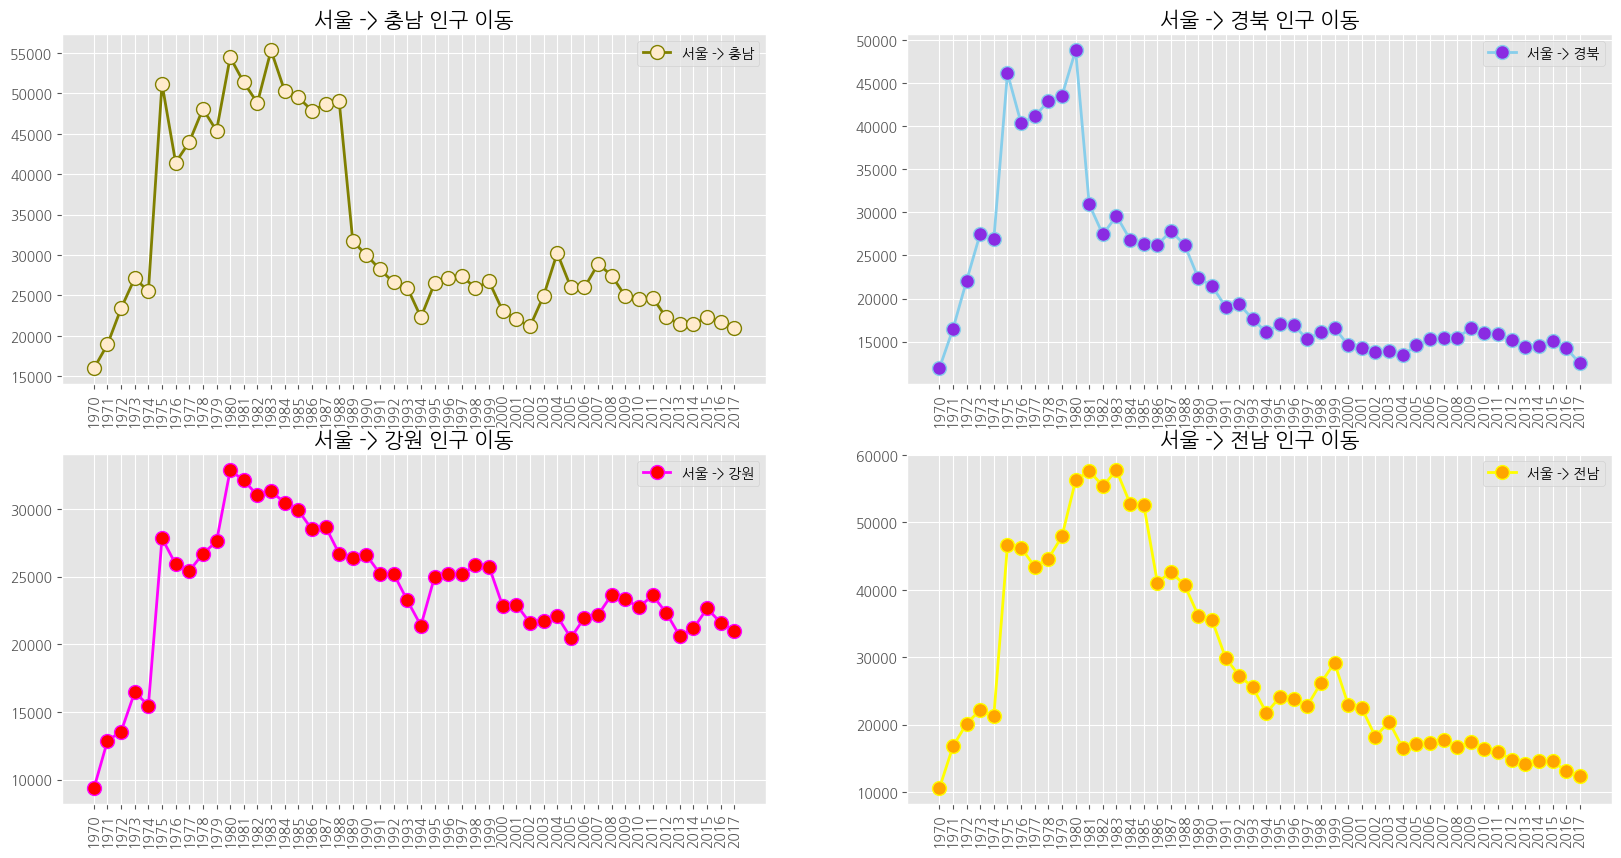

In [ ]:
# 서울에서 '충청남도', '경상북도', '강원도', '전라남도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(1970, 2018)))
df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]

# 스타일 서식 지정
plt.style.use('ggplot')

# 그래프 객체 생성(figure에 1개의 서브 플롯 생성)
fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

# axe 객체에 plot 함수로 그래프 출력
ax1.plot(col_years, df_4.loc['충청남도', :], marker='o', markerfacecolor='blanchedalmond',
         markersize=10, color='olive', linewidth=2, label='서울 -> 충남')
ax2.plot(col_years, df_4.loc['경상북도', :], marker='o', markerfacecolor='blueviolet',
         markersize=10, color='skyblue', linewidth=2, label='서울 -> 경북')
ax3.plot(col_years, df_4.loc['강원도', :], marker='o', markerfacecolor='red',
         markersize=10, color='magenta', linewidth=2, label='서울 -> 강원')
ax4.plot(col_years, df_4.loc['전라남도', :], marker='o', markerfacecolor='orange',
         markersize=10, color='yellow', linewidth=2, label='서울 -> 전남')

# 범례 표시
ax1.legend(loc='best')
ax2.legend(loc='best')
ax3.legend(loc='best')
ax4.legend(loc='best')

# 차트 제목 추가
ax1.set_title('서울 -> 충남 인구 이동', size=15)
ax2.set_title('서울 -> 경북 인구 이동', size=15)
ax3.set_title('서울 -> 강원 인구 이동', size=15)
ax4.set_title('서울 -> 전남 인구 이동', size=15)

# 축 눈금 라벨 지정 및 90도 회전
ax1.set_xticklabels(col_years, rotation=90)
ax2.set_xticklabels(col_years, rotation=90)
ax3.set_xticklabels(col_years, rotation=90)
ax4.set_xticklabels(col_years, rotation=90)

plt.show()  # 변경사항 저장하고 그래프 출력

## 1-2 면적 그래프

### 면적 그래프??

- 각 열의 데이터를 선 그래프로 그린 뒤, 선과 x축 사이의 공간을 색으로 채운 그래프
- 그리는 방법: `plot()` 메소드에 `kind=’area’` 추가
    - 투명도: alpha, 기본값(0.5)
- `stacked=False` 옵션: 각 열의 선 그래프들이 누적되지 않고 서로 겹치도록 표시
- `stacked=True` 옵션: (기본) 각 열의 그래프를 이전 열 위에 쌓아 올림, 맨 위 선의 높이가 모든 열의 합계가 됨
- `idex.map(함수)` : 인덱스의 각 라벨에 함수를 적용한 결과로 새 index 객체를 반환

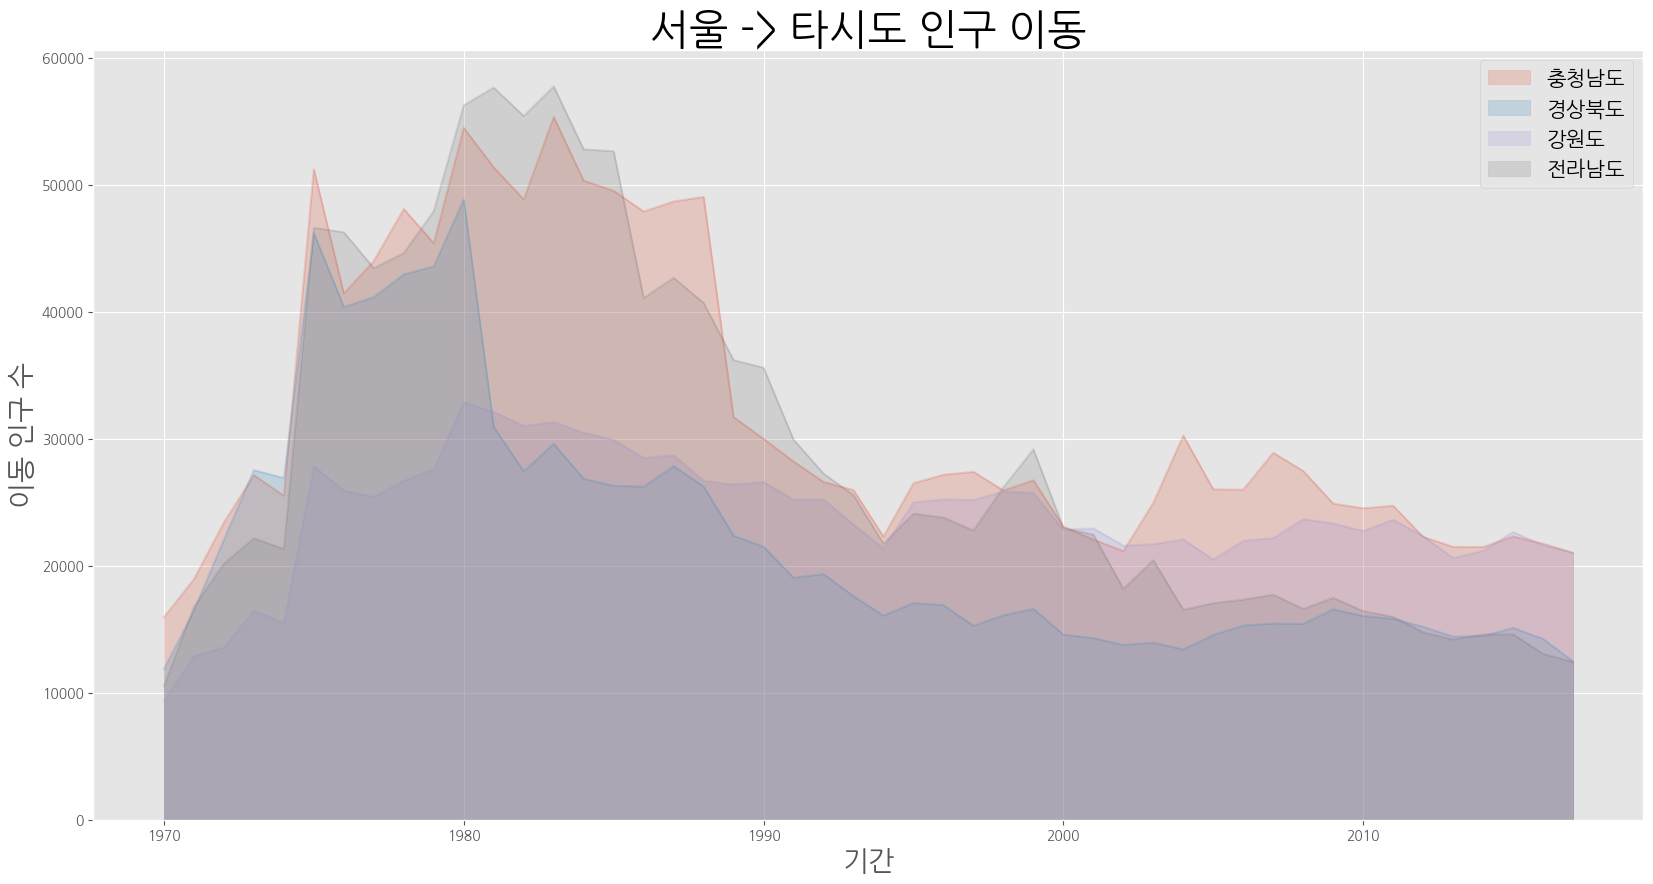

In [ ]:
# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
#mask가 True인 행만 골라서 df_seoul에 저장
df_seoul = df[mask]
#전출지별' 열을 삭제
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 서울에서 '충청남도', '경상북도', '강원도', '전라남도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(1970, 2018)))
df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]
df_4 = df_4.transpose()

# 스타일 서식 지정
plt.style.use('ggplot')

# 데이터프레임의 인덱스를 정수형으로 변경(x축 눈금 라벨 표시)
df_4.index = df_4.index.map(int)

# 면적 그래프 그리기
df_4.plot(kind='area', stacked=False, alpha=0.2, figsize=(20, 10))

plt.title('서울 -> 타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size=20)
plt.legend(loc='best', fontsize=15)

plt.show()

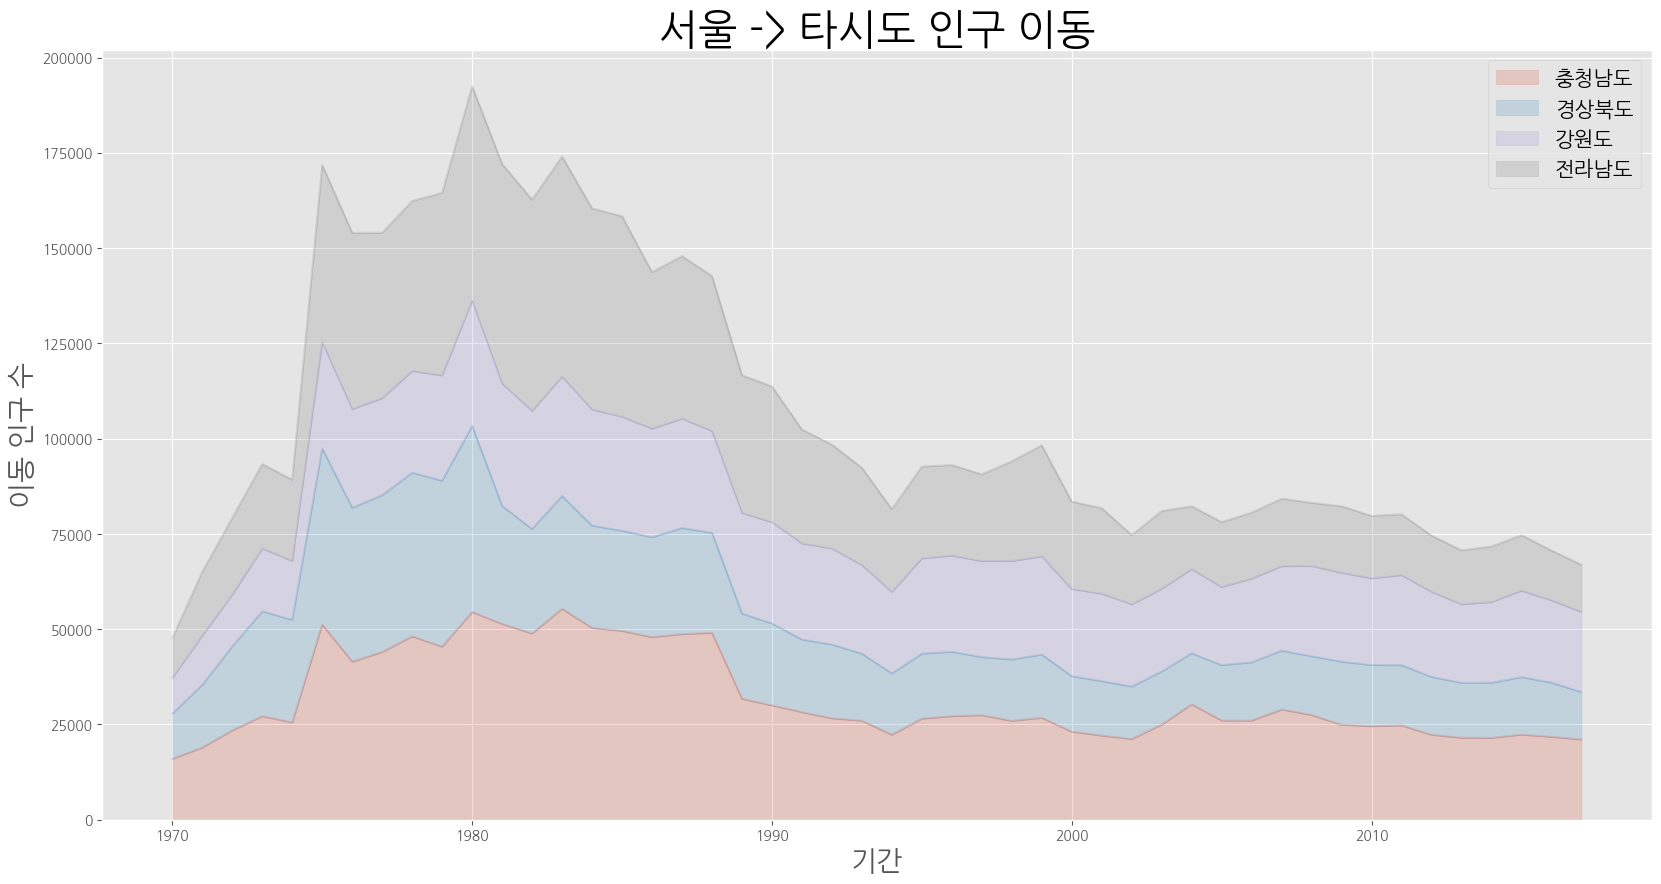

In [ ]:
# 데이터프레임의 인덱스를 정수형으로 변경(x축 눈금 라벨 표시)
df_4.index = df_4.index.map(int)

# 면적 그래프 그리기
df_4.plot(kind='area', stacked=True, alpha=0.2, figsize=(20, 10))

plt.title('서울 -> 타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size=20)
plt.legend(loc='best', fontsize=15)

plt.show()

<class 'matplotlib.axes._axes.Axes'>


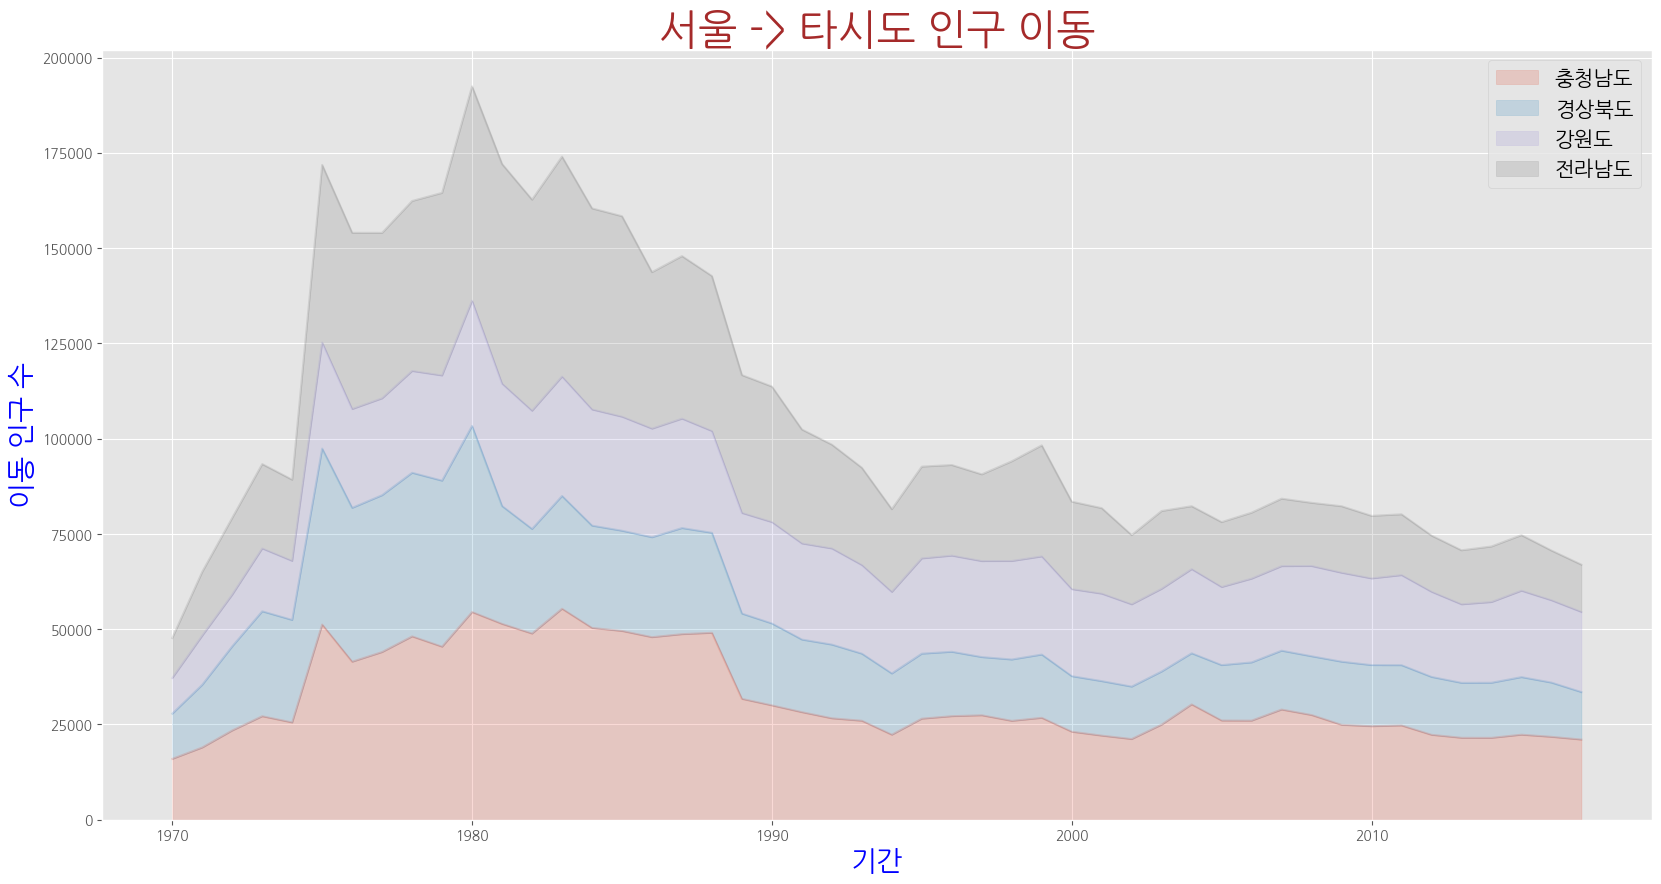

In [ ]:
# 데이터프레임의 인덱스를 정수형으로 변경(x축 눈금 라벨 표시)
df_4.index = df_4.index.map(int)

# 면적 그래프 axe 객체 생성
ax = df_4.plot(kind='area', stacked=True, alpha=0.2, figsize=(20, 10))
print(type(ax))

# axe 객체 설정 변경
ax.set_title('서울 -> 타시도 인구 이동', size=30, color='brown', weight='bold')
ax.set_ylabel('이동 인구 수', size=20, color='blue')
ax.set_xlabel('기간', size=20, color='blue')
ax.legend(loc='best', fontsize=15)

plt.show()

## 1-3 막대 그래프

### 세로형 막대 그래프

- `.plot()`  메소드 + `kind=’bar’` 옵션
- `plt.ylim(a,b)` : a≤y축의 범위≤b

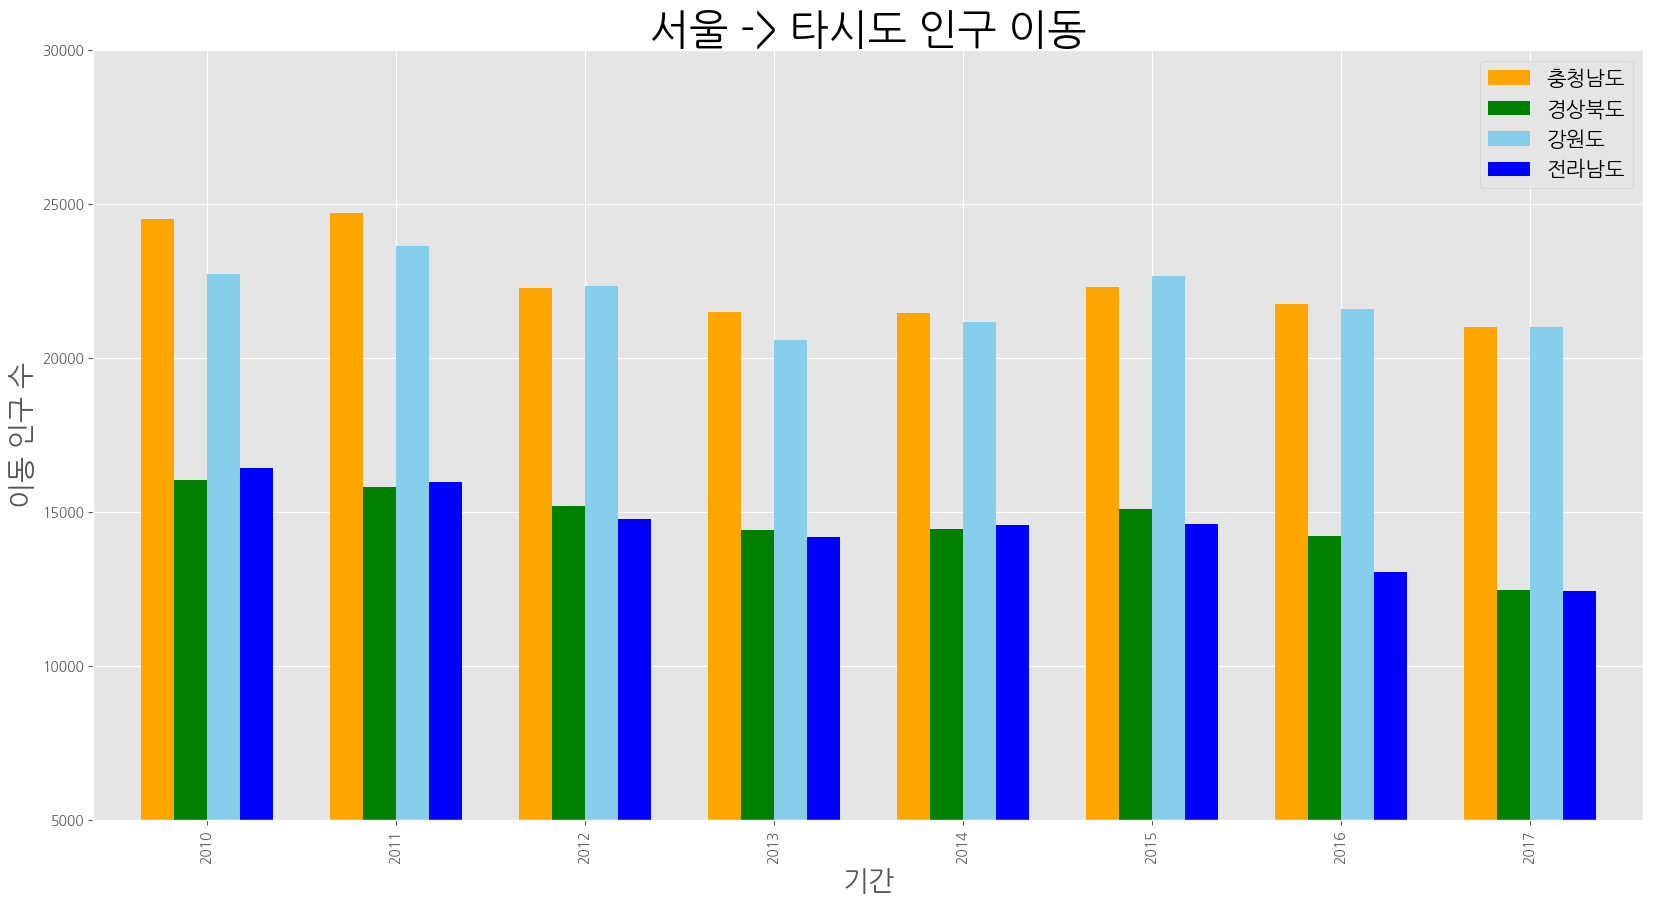

In [ ]:
# 서울에서 '충청남도', '경상북도', '강원도', '전라남도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(2010, 2018)))
df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]
df_4 = df_4.transpose()

# 스타일 서식 지정
plt.style.use('ggplot')

# 데이터프레임의 인덱스를 정수형으로 변경(x축 눈금 라벨 표시)
df_4.index = df_4.index.map(int)

# 막대 그래프 그리기
df_4.plot(kind='bar', figsize=(20, 10), width=0.7,
          color=['orange', 'green', 'skyblue', 'blue'])

plt.title('서울 -> 타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size=20)
# y축을 5000~30000으로 지정
plt.ylim(5000, 30000)
plt.legend(loc='best', fontsize=15)

plt.show()

### 가로형 막대 그래프

- 각 변수 사이의 값의 크기 차이를 설명하는데 적합
- `.plot()`  메소드 + `kind=’barh’` 옵션

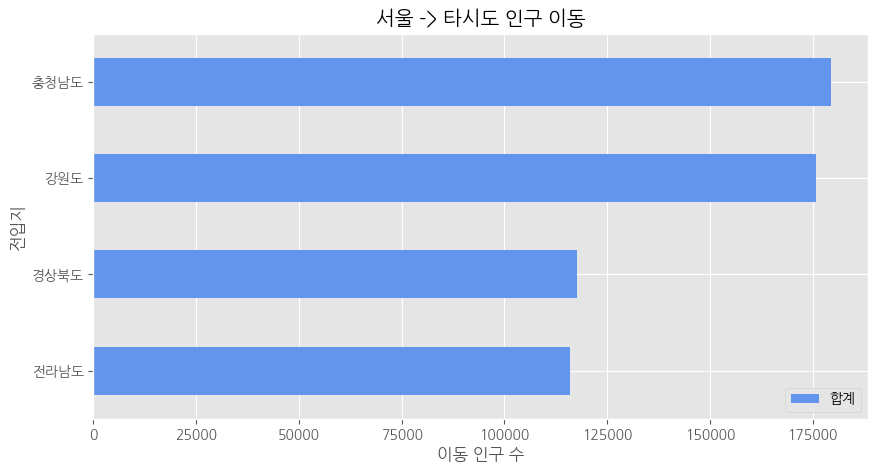

In [ ]:
# 서울에서 '충청남도', '경상북도', '강원도', '전라남도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(2010, 2018)))
df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]

# 2010-2017년 이동 인구 수를 합계하여 새로운 열로 추가
df_4['합계'] = df_4.sum(axis=1)

# 가장 큰 값부터 정렬
df_total = df_4[['합계']].sort_values(by='합계', ascending=True)

# 스타일 서식 지정
plt.style.use('ggplot')

# 수평 막대 그래프 그리기
df_total.plot(kind='barh', color='cornflowerblue', width=0.5, figsize=(10, 5))

plt.title('서울 -> 타시도 인구 이동')
plt.ylabel('전입지')
plt.xlabel('이동 인구 수')

plt.show()

### 보조축 활용하기

- `Series.shift(n)` : 데이터를 n칸 아래로 밀어낸 새 시리즈를 반환
    - 앞 n 칸은 `NaN`이 됨
    - `shift(1)`: 각 행에 바로 전 행 값이 놓임
- `.twinx()` : 기존 Axes와 x축을 공유하면서 오른쪽에 독립된 y축을 가진 새 Axes를 만들어 반환
    - 두 Axes는 같은 자리에 겹쳐 그려지고 y축 범위와 눈금은 따로 설정됨
- `.legend(loc='upper left')` : 범례를 왼쪽 위에 표시
    - `.legend(loc='upper right')` : 오른쪽 위

Saving 남북한발전전력량.xlsx to 남북한발전전력량.xlsx


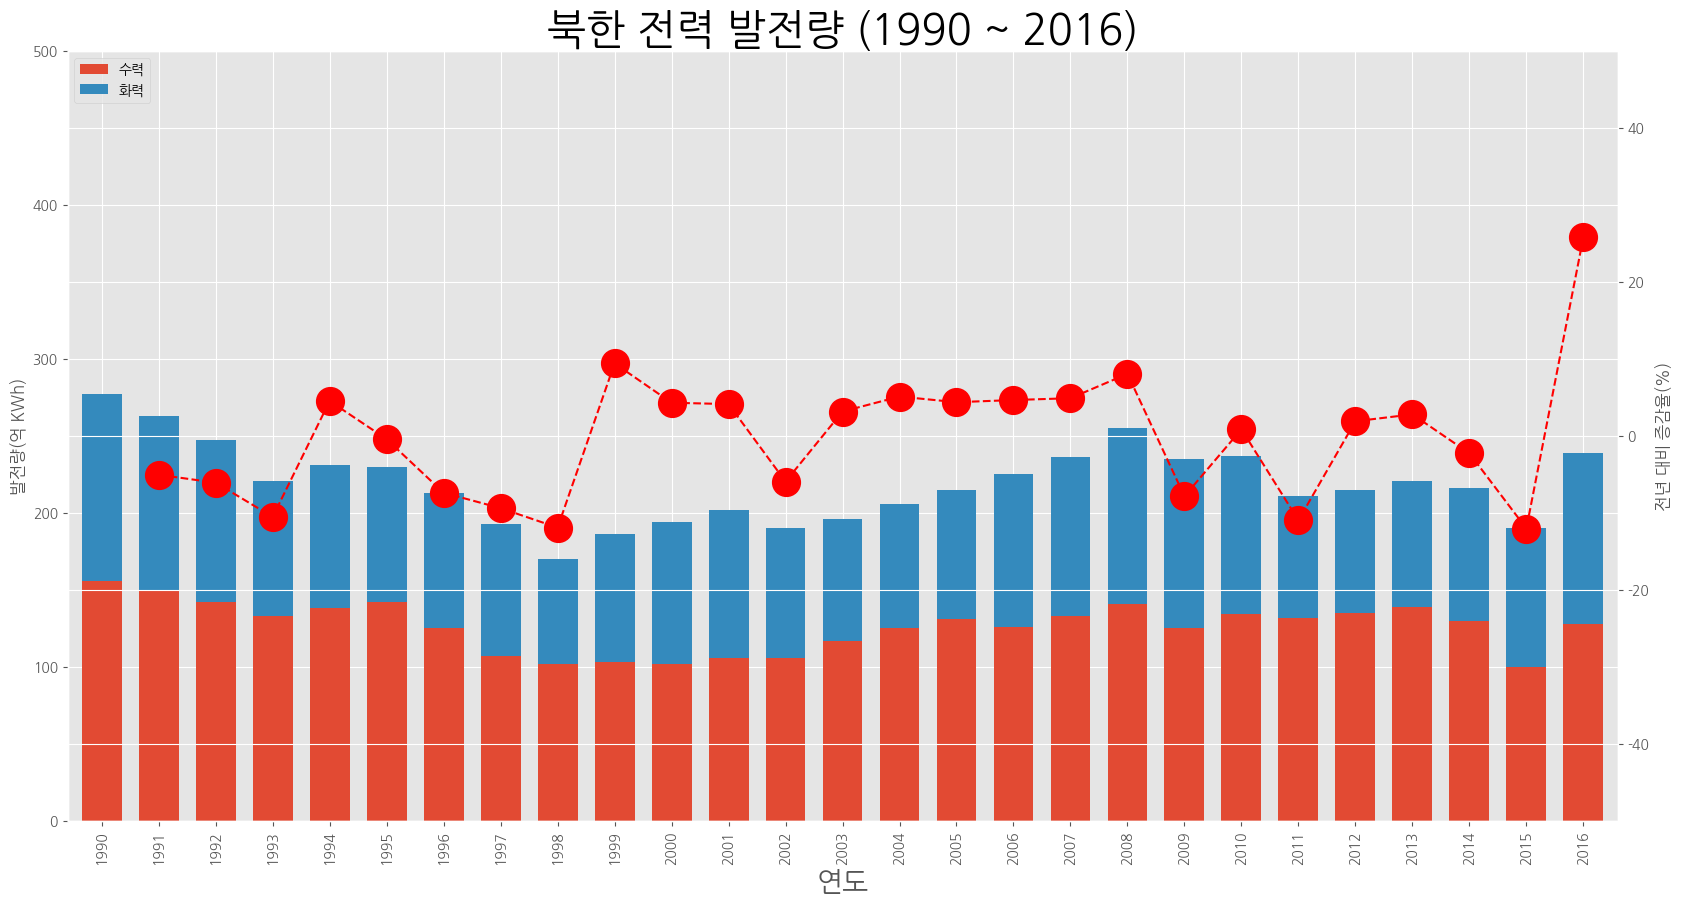

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

# matplotlib 한글 폰트 오류 문제 해결
!apt-get -qq install -y fonts-nanum                                  # [추가] 나눔 폰트 설치
from matplotlib import font_manager, rc
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"         # [수정] 폰트 파일 위치
font_manager.fontManager.addfont(font_path)                           # [추가] matplotlib에 폰트 등록
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# Excel 데이터를 데이터프레임으로 변환
df = pd.read_excel('./남북한발전전력량.xlsx')
df = df.loc[5:9]
df.drop('전력량 (억㎾h)', axis='columns', inplace=True)
df.set_index('발전 전력별', inplace=True)
df = df.T

# 증감률(변동률) 계산
df = df.rename(columns={'합계':'총발전량'})
#총발전량을 한 칸 아래로 민 값, 즉 전년도 발전량을 새 열로 추가. 1990년 행은 NaN
df['총발전량 - 1년'] = df['총발전량'].shift(1)
df['증감률'] = ((df['총발전량'] / df['총발전량 - 1년']) - 1) * 100

# 2축 그래프 그리기
ax1 = df[['수력', '화력']].plot(kind='bar', figsize=(20, 10), width=0.7, stacked=True)
ax2 = ax1.twinx()
ax2.plot(df.index, df.증감률, ls='--', marker='o', markersize=20,
         color='red', label='전년대비 증감률(%)')

ax1.set_ylim(0, 500)
ax2.set_ylim(-50, 50)

ax1.set_xlabel('연도', size=20)
ax1.set_ylabel('발전량(억 KWh)')
ax2.set_ylabel('전년 대비 증감율(%)')

plt.title('북한 전력 발전량 (1990 ~ 2016)', size=30)
ax1.legend(loc='upper left')

plt.show()

## 1-4 히스토그램

> 히스토그램은 변수가 하나인 단변수 데이터의 빈도수를 그래프로 표현한다
>
- `.plot()`  메소드 + `kind=’hist’` 옵션
- `bins=` : 정수 데이터의 최솟값~최댓값을 그 개수만큼 같은 너비의 구간으로 나눔
    - 기본값: 10
    - 리스트를 주면 그 값들을 구간의 경계로 사용

Saving auto-mpg.csv to auto-mpg.csv


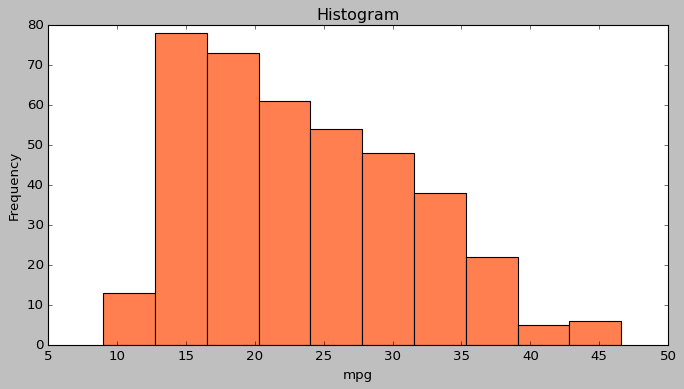

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

# 파일 업로드 (실행 시 '파일 선택' 버튼이 나타난)
from google.colab import files
uploaded = files.upload()

plt.style.use('classic')   # 스타일 서식 지정

# read_csv() 함수로 df 생성
df = pd.read_csv('./auto-mpg.csv', header=None)

# 열 이름 지정
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
              'acceleration', 'model year', 'origin', 'name']

# 연비(mpg) 열에 대한 히스토그램 그리기
df['mpg'].plot(kind='hist', bins=10, color='coral', figsize=(10, 5))

# 그래프 꾸미기
plt.title('Histogram')
plt.xlabel('mpg')
plt.show()

## 1-5 산점도

> 산점도는 서로 다른 두 변수 사이의 관계를 보여주는 그래프
>
- 2개의 연속 변수를 x축, y축에 놓고
- 데이터 값이 위치하는 좌표를 찾아서 점으로 표시
- `.plot()`  메소드 + `kind=’scatter’` 옵션+ `'o’` 옵션
- `x='열 이름’` : x축에 놓을 열
- `y=’열 이름’`: y축에 놓을 열
- `c`: 점의 색
    - 색 이름 문자열을 주면 모든 점이 같은 색
    - 숫자 배열, 숫자 열 이름이면 값에 따라 다른 색이 칠해짐
- `s`: 점의 크기
    - 단위: 포인트(면적)
    - 숫자 하나: 모든 점이 같은 크기
    - 숫자 배열: 점마다 크기 달라짐
- `cmap` : 컬러맵, 숫자 배열을 줬을 때 숫자를 색으로 바꾸는 규칙
- 버블 차트: 점에 크기에 변화를 준 그래프

Saving auto-mpg.csv to auto-mpg (1).csv


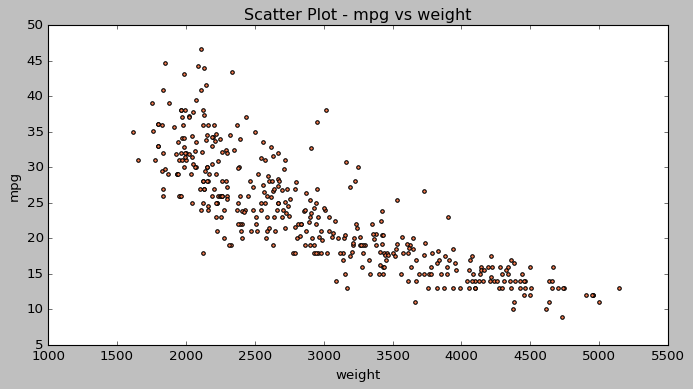

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

# 파일 업로드 (실행 시 '파일 선택' 버튼이 나타난)
from google.colab import files
uploaded = files.upload()

plt.style.use('classic')   # 스타일 서식 지정

# read_csv() 함수로 df 생성
df = pd.read_csv('./auto-mpg.csv', header=None)

# 열 이름 지정
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
              'acceleration', 'model year', 'origin', 'name']

# 연비(mpg)와 차중(weight) 열에 대한 산점도 그리기
df.plot(kind='scatter', x='weight', y='mpg', c='coral', s=10, figsize=(10, 5))
plt.title('Scatter Plot - mpg vs weight')
plt.show()

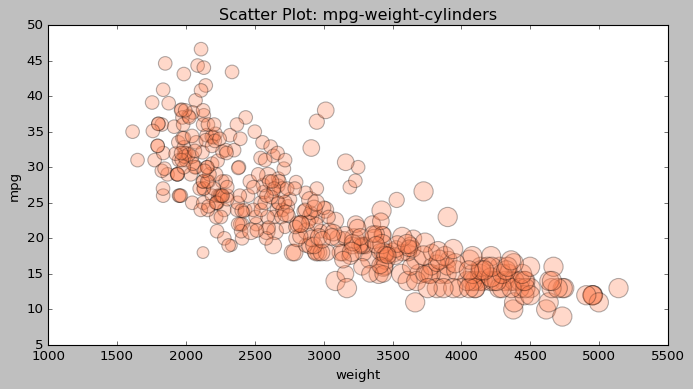

In [ ]:
# cylinders 개수의 상대적 비율을 계산하여 시리즈 생성
cylinders_size = df.cylinders / df.cylinders.max() * 300

# 3개의 변수로 산점도 그리기
df.plot(kind='scatter', x='weight', y='mpg', c='coral', figsize=(10, 5),
        s=cylinders_size, alpha=0.3)
plt.title('Scatter Plot: mpg-weight-cylinders')
plt.show()

### 그래프를 그림 파일로 저장

- `plt.savefig("저장할위치/파일이름.확장자")`
- `transparent=True` : 배경을 투명하게 지정

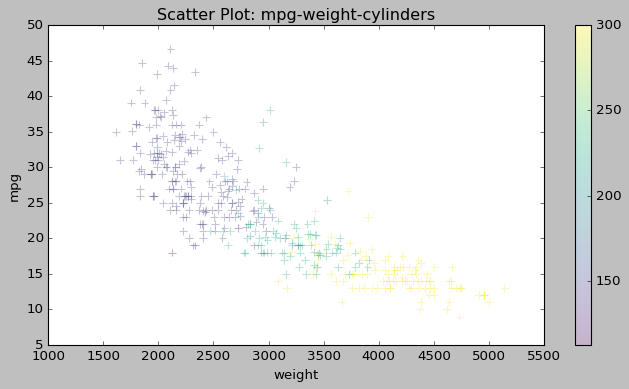

In [ ]:
# cylinders 개수의 상대적 비율을 계산하여 시리즈 생성
cylinders_size = df.cylinders / df.cylinders.max() * 300

# 3개의 변수로 산점도 그리기
df.plot(kind='scatter', x='weight', y='mpg', marker='+', figsize=(10, 5),
        cmap='viridis', c=cylinders_size, s=50, alpha=0.3)
plt.title('Scatter Plot: mpg-weight-cylinders')

plt.savefig("./scatter.png")
plt.savefig("./scatter_transparent.png", transparent=True)

plt.show()

## 1-6 파이 차트

> 파이 차트는 원을 파이 조각처럼 나누어 전체에서 각 부분이 차지하는 비율을 보여주는 그래프
>
- `.plot()`  메소드 + `kind=’pie’` 옵션
    - `autopct` : 각 조각 안에 그 조각이 전체에서 차지하는 백분율을 자동으로 표시하는 옵션
        - 기본값: None
        - 줄 수 있는 값: `'%[전체자릿수].[소수자릿수]f%%’` , `함수이름` (괄호없이)
    - `startangle` : 첫 번째 조각이 시작하는 가도를 지정하는 옵션
        - 기준선: 원의 중심에서 오른쪽 수평 방향(3시 방향 = 0°)
        - 값만큼 반시계방향으로 회전한 위치에서 첫 조각이 시작
        - 기본값: 0
- `DataFrame.groupby('열 이름')` : 지정한 열의 값이 같은 행끼리 묶은 그룹 객체를 반환
- `plt.axis('equal')` : 원의 가로 세로 비율을 같게 함

Saving auto-mpg.csv to auto-mpg (2).csv
           mpg  cylinders  displacement  \
origin                                    
1       5000.8       1556       61229.5   
2       1952.4        291        7640.0   
3       2405.6        324        8114.0   

                                               horsepower    weight  \
origin                                                                
1       130.0165.0150.0150.0140.0198.0220.0215.0225.01...  837121.0   
2       46.0087.0090.0095.00113.090.0070.0076.0060.005...  169631.0   
3       95.0088.0088.0095.0065.0069.0095.0097.0092.009...  175477.0   

        acceleration  model year  \
origin                             
1             3743.4       18827   
2             1175.1        5307   
3             1277.6        6118   

                                                     name  count  
origin                                                            
1       chevrolet chevelle malibubuick skylark 320plym...    249  
2     

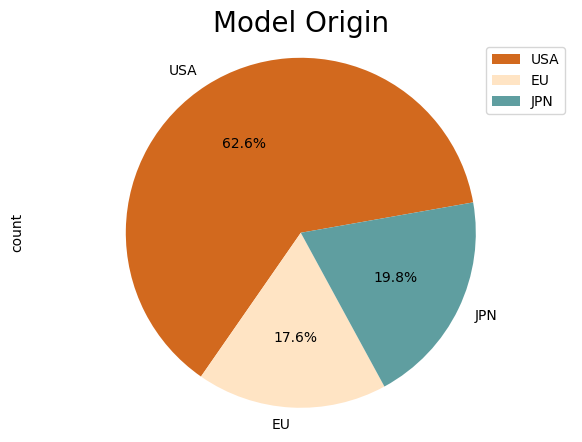

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

# 파일 업로드 (실행 시 '파일 선택' 버튼이 나타난다)
from google.colab import files
uploaded = files.upload()

plt.style.use('default')   # 스타일 서식 지정

# read_csv() 함수로 df 생성
df = pd.read_csv('./auto-mpg.csv', header=None)

# 열 이름 지정
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
              'acceleration', 'model year', 'origin', 'name']

# 데이터 개수 카운트를 위해 값 1을 가진 열 추가
df['count'] = 1
df_origin = df.groupby('origin').sum()   # origin 열을 기준으로 그룹화, 합계 연산
print(df_origin.head())                  # 그룹 연산 결과 출력

# 제조국가(origin) 값을 실제 지역명으로 변경
df_origin.index = ['USA', 'EU', 'JPN']

# 제조국가(origin) 열에 대한 파이 차트 그리기 - count 열 데이터 사용
df_origin['count'].plot(kind='pie',
                        figsize=(7, 5),
                        autopct='%1.1f%%',     # 퍼센트 % 표시
                        startangle=10,         # 파이 조각을 나누는 시작점(각도 표시)
                        colors=['chocolate', 'bisque', 'cadetblue']   # 색상 리스트
                        )

plt.title('Model Origin', size=20)
plt.axis('equal')    # 파이 차트의 비율을 같게(원에 가깝게) 조정
plt.legend(labels=df_origin.index, loc='upper right')   # 범례 표시
plt.show()

## 1-7 박스 플롯

> 박스 플롯은 범주형 데이터의 분포를 파악하는데 적합하다
>

**`Axes.boxplot()`**

- `ax.boxplot(x=[데이터1, 데이터2, ...], labels=[라벨1, 라벨2, ...], vert=True/False)`
    - `x` : 박스 플롯을 그릴 데이터
    - `vert=True` : 수직 박스 플롯(기본값)
    - `vert=False` : 수평 박스 플롯

Saving auto-mpg.csv to auto-mpg (3).csv


/tmp/ipykernel_759/99526942.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(x=[df[df['origin']==1]['mpg'],
/tmp/ipykernel_759/99526942.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(x=[df[df['origin']==1]['mpg'],


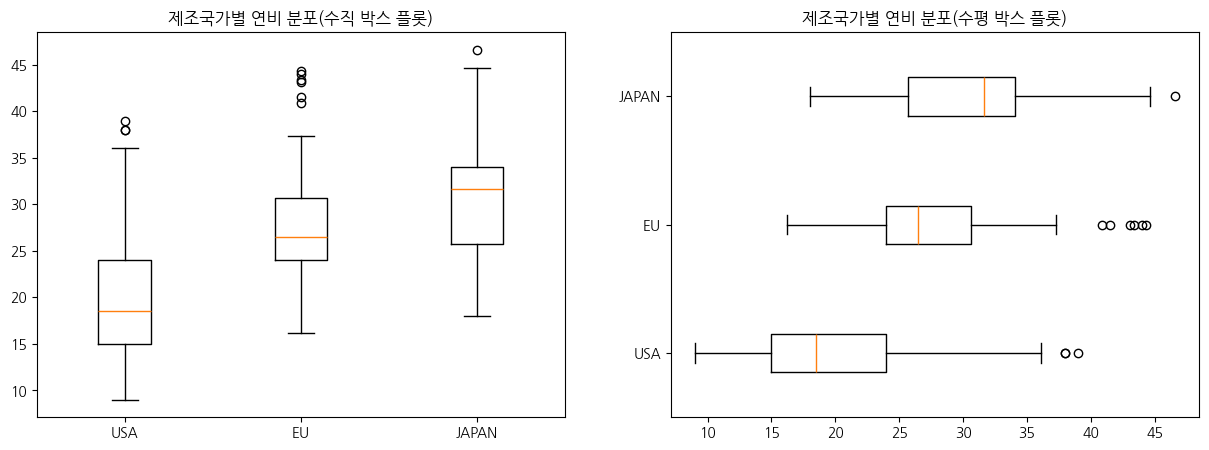

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

# 파일 업로드 (실행 시 '파일 선택' 버튼이 나타난다)
from google.colab import files
uploaded = files.upload()

# matplotlib 한글 폰트 오류 문제 해결
!apt-get -qq install -y fonts-nanum                                  # [추가] 나눔 폰트 설치
from matplotlib import font_manager, rc
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"         # [수정] 폰트 파일 위치
font_manager.fontManager.addfont(font_path)                           # [추가] matplotlib에 폰트 등록
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# read_csv() 함수로 df 생성
df = pd.read_csv('./auto-mpg.csv', header=None)

# 열 이름 지정
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
              'acceleration', 'model year', 'origin', 'name']

# 그래프 객체 생성(figure에 2개의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# axe 객체에 boxplot 메소드로 그래프 출력
ax1.boxplot(x=[df[df['origin']==1]['mpg'],
               df[df['origin']==2]['mpg'],
               df[df['origin']==3]['mpg']],
            labels=['USA', 'EU', 'JAPAN'])

ax2.boxplot(x=[df[df['origin']==1]['mpg'],
               df[df['origin']==2]['mpg'],
               df[df['origin']==3]['mpg']],
            labels=['USA', 'EU', 'JAPAN'],
            vert=False)

ax1.set_title('제조국가별 연비 분포(수직 박스 플롯)')
ax2.set_title('제조국가별 연비 분포(수평 박스 플롯)')

plt.show()

## Seaborn 라이브러리

### 2-1 데이터셋 가져오기

- `sns.load_dataset("데이터셋이름")`: Seaborn에 내장된 예제 데이터셋을 이름으로 불러와 DataFrame으로 반환하는 함수

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import seaborn as sns

# titanic 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# titanic 데이터셋 살펴보기
print(titanic.head())
print('\n')
print(titanic.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-

### 2-3 회귀선이 있는 산점도

- `plt.figure(figsize=(가로, 세로))` : 그래프 전체 Figure 객체를 만듦, 단위: 인치
- `sns.set_style("테마이름")` : 그래프의 배경 스타일 지정
    - `darkgrid`
    - `whitegrid`
    - `dark`
    - `white`
    - `ticks`
- `sns.regplot(x="x축열이름", y="y축열이름", data=데이터프레임, ax=axe객체, fit_reg=True 또는 False)` : 연속형 변수 2개의 산점도를 그리고 선형회귀분석으로 구한 회귀선을 함께 그림
    - `ax` : 그래프를 그릴 서브 플롯 지정
    - `fit_reg=False` : 회귀선 그리지 않음(기본값: True)

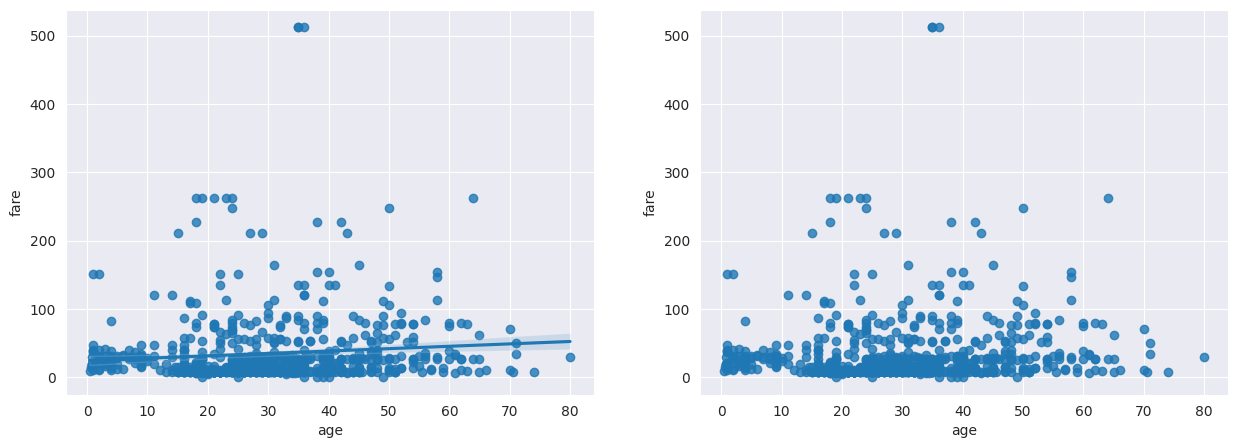

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정 (5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('darkgrid')

# 그래프 객체 생성 (figure에 2개의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# 그래프 그리기 - 선형회귀선 표시 (fit_reg=True)
sns.regplot(x='age',        # x축 변수
            y='fare',       # y축 변수
            data=titanic,   # 데이터
            ax=ax1)         # axe 객체 - 1번째 그래프

# 선형회귀선 미표시 (fit_reg=False)
sns.regplot(x='age',        # x축 변수
            y='fare',       # y축 변수
            data=titanic,   # 데이터
            ax=ax2,         # axe 객체 - 2번째 그래프
            fit_reg=False)  # 회귀선 미표시

plt.show()

### 2-4 히스토그램/커널 밀도 그래프

- `sns.distplot(데이터, hist=True 또는 False, kde=True 또는 False, ax=axe객체)` : 데이터 분포를 그리는 함수
    - `hist=False` : 히스토그램이 표시되지 않음, True가 기본값
    - `kde=True` : 커널 밀도 그래프를 표시하지 않음
- 커널 밀도 함수: 그래프와 x축 사이의 면적이 1이 되도록 그리는 밀도 분포 함수
- axe객체.set_title("제목") : 서브 플롯 제목 붙이기

/tmp/ipykernel_759/2017015649.py:20: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic['fare'], ax=ax1)
/tmp/ipykernel_759/2017015649.py:23: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic['fare'], hist=False, ax=ax2)
/tmp/ipykernel_759/2017015649.py:26: UserWarning: 

`distpl

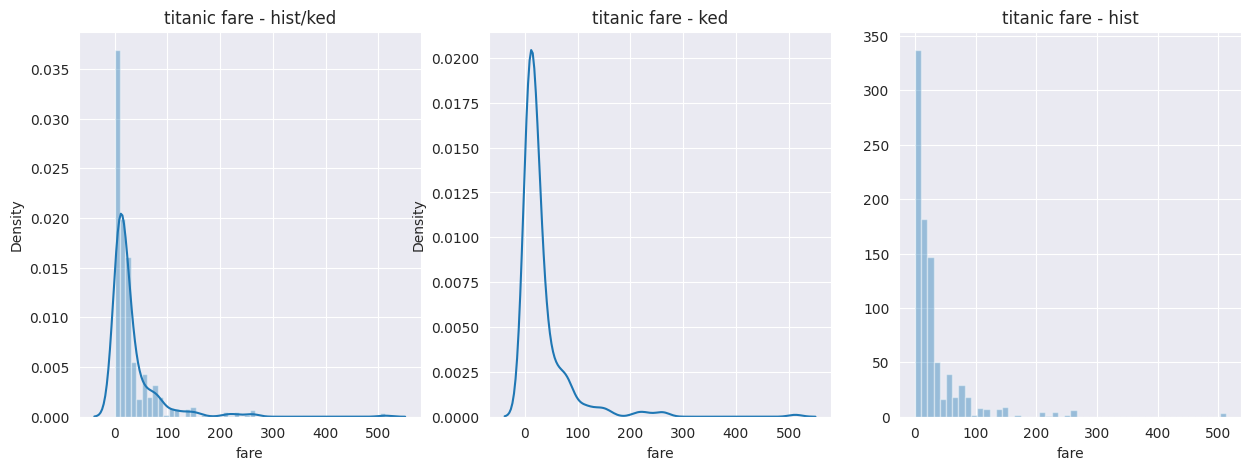

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정 (5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('darkgrid')

# 그래프 객체 생성 (figure에 3개의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

# 기본값
sns.distplot(titanic['fare'], ax=ax1)

# hist=False
sns.distplot(titanic['fare'], hist=False, ax=ax2)

# kde=False
sns.distplot(titanic['fare'], kde=False, ax=ax3)

# 차트 제목 표시
ax1.set_title('titanic fare - hist/ked')
ax2.set_title('titanic fare - ked')
ax3.set_title('titanic fare - hist')

plt.show()

### 2-5 히트맵

**`sns.heatmap(데이터프레임, annot=True 또는 False, fmt="포맷코드", cmap="컬러맵이름", linewidth=숫자, cbar=True 또는 False)`**

- 2차원 표 형태 데이터의 각 값을 색의 진하기로 나타내는 히트맵을 그리는 함수
- `annot` : 셀 안에 값을 표시할지 정함
- `fmt` : 셀에 표시할 값의 문자열 포맷 코드
- `cmap` : 값의 크기에 대응시킬 컬러맵 지정
- `linewidth` : 셀 사이 구분선의 두께
- `cbar` : 값-색상 대응을 보여주는 컬라 바를 표시하지를 정함

**`데이터프레임.pivot_table(index=[행으로쓸열], columns=[열로쓸열], values=집계할열, aggfunc="집계방식")`**

- 한 열의 값을 행 인덱스로, 다른 열의 값을 열 이름으로 놓고, 각 (행, 열) 조합에 대해 집계한 값을 채운 표(피벗테이블)를 만드는 메소드
- `aggfunc="집계방식”` : 각 조합에 속하는 데이터의 개수를 값으로 함

/tmp/ipykernel_759/3640839590.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = titanic.pivot_table(index=['sex'], columns=['class'], aggfunc='size')


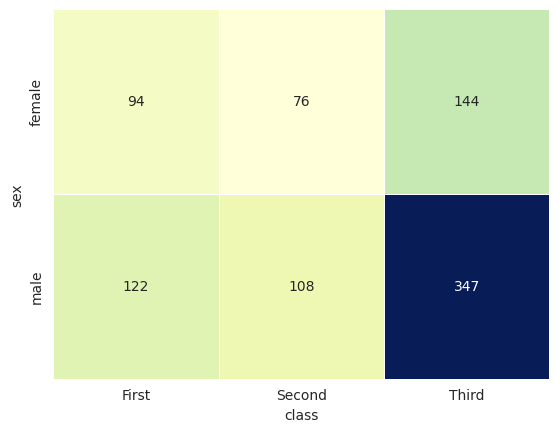

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정 (5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('darkgrid')

# 피벗테이블로 범주형 변수를 각각 행, 열로 재구분하여 정리
table = titanic.pivot_table(index=['sex'], columns=['class'], aggfunc='size')

# 히트맵 그리기
sns.heatmap(table,                # 데이터프레임
            annot=True, fmt='d',  # 데이터 값 표시 여부, 정수형 포맷
            cmap='YlGnBu',        # 컬러 맵
            linewidth=.5,         # 구분 선
            cbar=False)           # 컬러 바 표시 여부

plt.show()

### 2-6 범주형 데이터의 산점도

- `hue="열이름”` : 지정한 열의 값(범주)별로 데이터를 다른 색으로 나눠 그리고 범례 표시
- `palette=”팔레트이름”` : 그래프에 사용할 색상 모음 지정
- `sns.stripplot(x="범주형열", y="값열", data=데이터프레임, ax=axe객체)` : 범주별로 데이터 점을 수직 방향 한 줄에 찍는 산점도
    - 값이 같거나 가까운 점들이 서로 겹칠 수 있음(분산 미고려)
- `sns.swarmplot(x="범주형열", y="값열", data=데이터프레임, ax=axe객체)` : 점이 서로 겹치지 않도록 좌우로 퍼뜨려 배치하는 산점도(분산 고려)

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 12.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


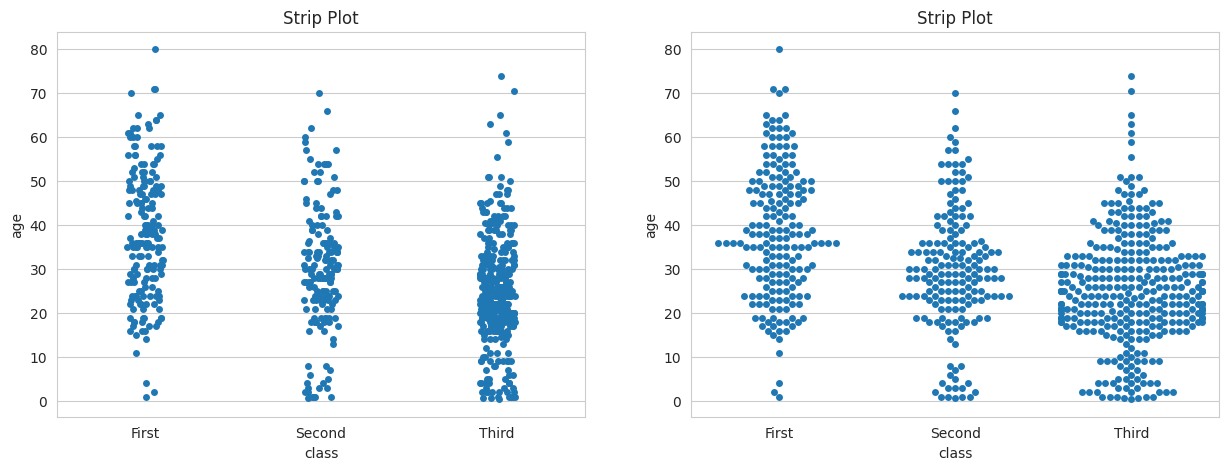

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정 (5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('whitegrid')

# 그래프 객체 생성 (figure에 2개의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# 이산형 변수의 분포 - 데이터 분산 미고려
sns.stripplot(x="class",      # x축 변수
              y="age",        # y축 변수
              data=titanic,   # 데이터셋 - 데이터프레임
              ax=ax1)         # axe 객체 - 1번째 그래프

# 이산형 변수의 분포 - 데이터 분산 고려 (중복 X)
sns.swarmplot(x="class",      # x축 변수
              y="age",        # y축 변수
              data=titanic,   # 데이터셋 - 데이터프레임
              ax=ax2)         # axe 객체 - 2번째 그래프

# 차트 제목 표시
ax1.set_title('Strip Plot')
ax2.set_title('Strip Plot')

plt.show()

### 2-7 막대 그래프

**`sns.barplot(x="범주형열", y="값열", data=데이터프레임, hue="구분열", dodge=True 또는 False, ax=axe객체)`**

- x축 범주별로 y축 값의 대푯값을 막대 높이로 나타내는 함수
- 막대 위의 검은 세로선: 추정값의 신뢰구간
- `hue` 지정: 각 x 범주 안에서 hue 열의 값별로 막대가 나뉨
- `dodge` : hue 막대를 옆으로 나눠 배치할지 정함
    - 기본값: `True`
    - `False`: 같은 위치에 겹쳐서 그림

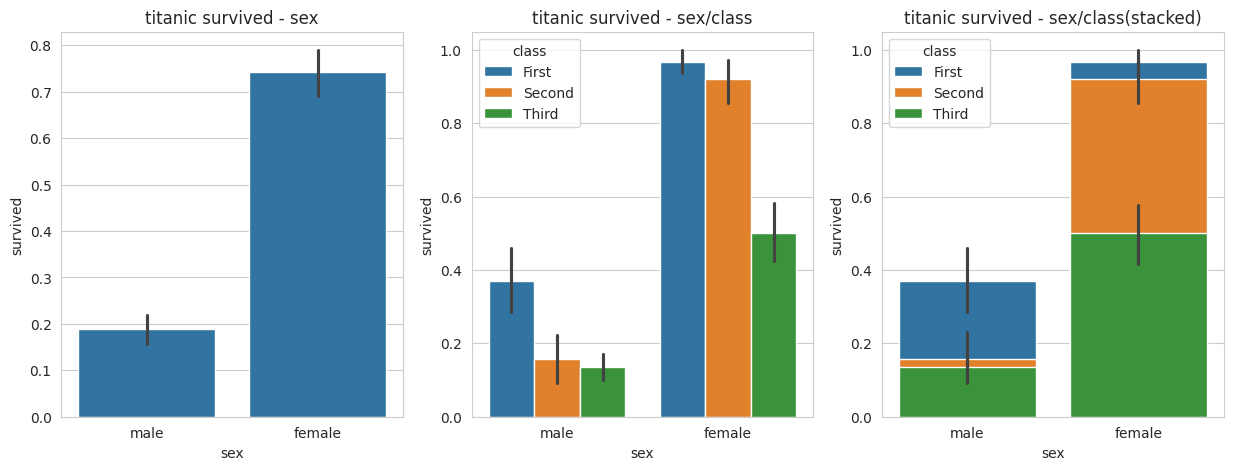

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정 (5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('whitegrid')

# 그래프 객체 생성 (figure에 3개의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

# x축, y축에 변수 할당
sns.barplot(x='sex', y='survived', data=titanic, ax=ax1)

# x축, y축에 변수 할당하고 hue 옵션 추가
sns.barplot(x='sex', y='survived', hue='class', data=titanic, ax=ax2)

# x축, y축에 변수 할당하고 hue 옵션을 추가하여 누적 출력
sns.barplot(x='sex', y='survived', hue='class', dodge=False, data=titanic, ax=ax3)

# 차트 제목 표시
ax1.set_title('titanic survived - sex')
ax2.set_title('titanic survived - sex/class')
ax3.set_title('titanic survived - sex/class(stacked)')

plt.show()

### 2-7 빈도 그래프

**`sns.countplot(x="범주형열", hue="구분열", palette="팔레트이름", dodge=True 또는 False, data=데이터프레임, ax=axe객체)`**

- x축 범주별로 데이터의 개수를 막대 높이로 나타내는 함수
- y축 값을 지정하지 않음
- palette : 막대 색 구성 설정

/tmp/ipykernel_759/4172798209.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', palette='Set1', data=titanic, ax=ax1)


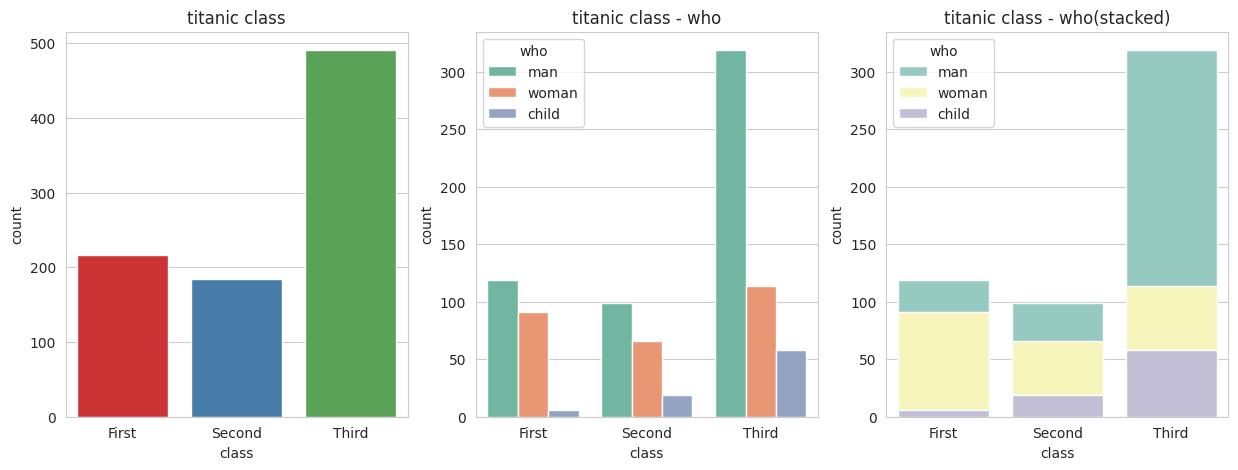

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정 (5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('whitegrid')

# 그래프 객체 생성 (figure에 3개의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

# 기본값
sns.countplot(x='class', palette='Set1', data=titanic, ax=ax1)

# hue 옵션에 'who' 추가
sns.countplot(x='class', hue='who', palette='Set2', data=titanic, ax=ax2)

# dodge=False 옵션 추가 (축 방향으로 분리하지 않고 누적 그래프 출력)
sns.countplot(x='class', hue='who', palette='Set3', dodge=False, data=titanic, ax=ax3)

# 차트 제목 표시
ax1.set_title('titanic class')
ax2.set_title('titanic class - who')
ax3.set_title('titanic class - who(stacked)')

plt.show()

### 2-8 박스 플롯/바이올린 그래프

**`sns.boxplot(x="범주형열", y="값열", hue="구분열", data=데이터프레임, ax=axe객체)`**

- 범주별 데이터 분포와 주요 통계 지표를 함께 보여주는 그래프
- 분산 파악 어렵

**`sns.violinplot(x="범주형열", y="값열", hue="구분열", data=데이터프레임, ax=axe객체)`**

- 박스 플롯에 커널 밀도 함수 그래프를 y축 방향 양쪽 대칭으로 추가한 그래프
- 분산 정도를 파악 가능

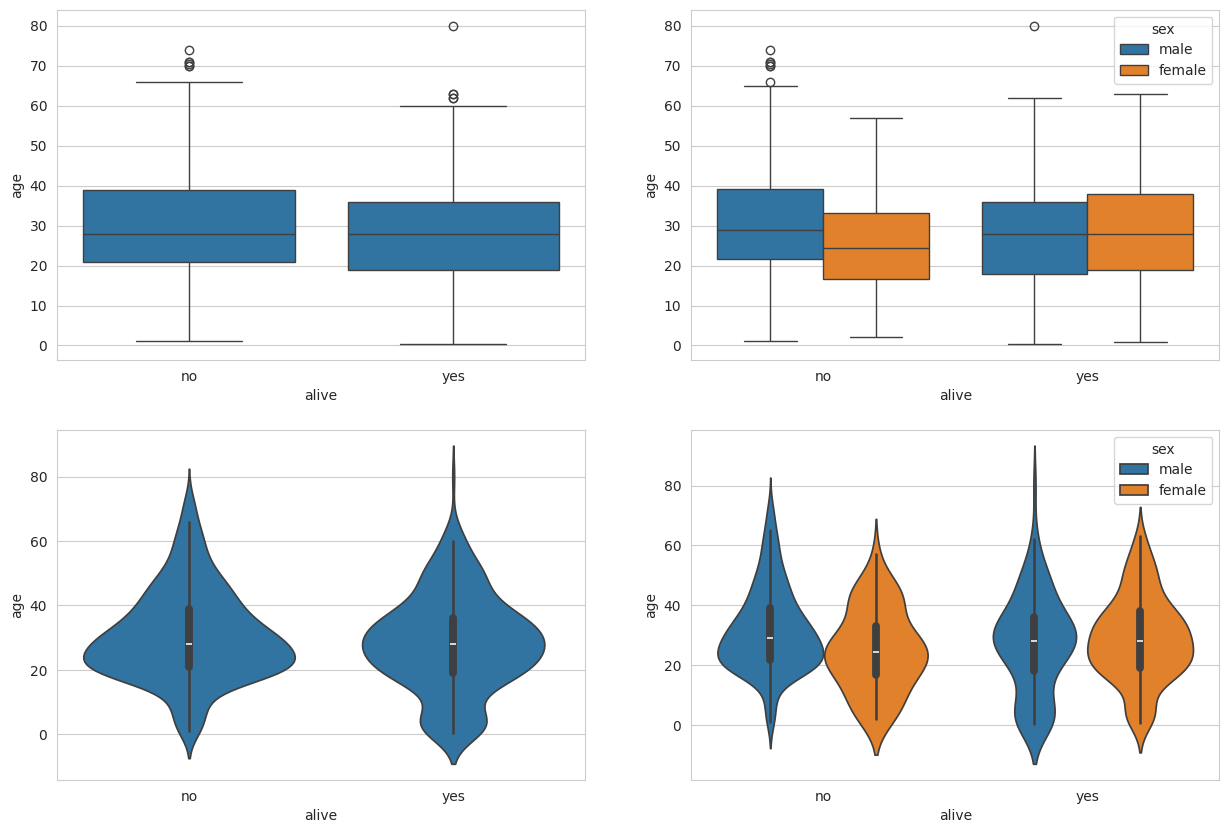

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정 (5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('whitegrid')

# 그래프 객체 생성 (figure에 4개의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 10))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

# 박스 플롯 - 기본값
sns.boxplot(x='alive', y='age', data=titanic, ax=ax1)

# 박스 플롯 - hue 변수 추가
sns.boxplot(x='alive', y='age', hue='sex', data=titanic, ax=ax2)

# 바이올린 그래프 - 기본값
sns.violinplot(x='alive', y='age', data=titanic, ax=ax3)

# 바이올린 그래프 - hue 변수 추가
sns.violinplot(x='alive', y='age', hue='sex', data=titanic, ax=ax4)

plt.show()

### 2-9 조인트 그래프

**`sns.jointplot(x="x축열", y="y축열", kind="그래프종류", data=데이터프레임)`**

- 두 변수의 관계를 보여주는 메인 그래프를 가운데에 그리고
- x축 위쪽, y축 오른쪽에 각 변수의 분포 그래프를 함께 그리는 함수
- `kind` 값에 따라 메인 그래프 종류가 달라짐
    - 생략: 산점도
    - `‘reg’` : 산점도+회귀선
    - `‘hex’` : 육각 산점도
    - `‘kde’` : 커널 밀도 그래프
- 자체 Figure를 새로 만들어서 `ax` 매개변수를 쓰지 않음

**`JointGrid객체.fig.suptitle("제목", size=글자크기)`**

- `jointplot()`이 반환한 객체의 Figure 전체에 제목을 붙임

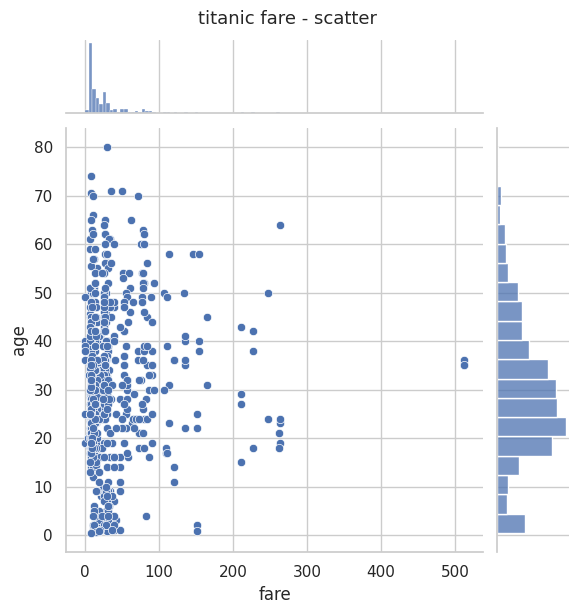

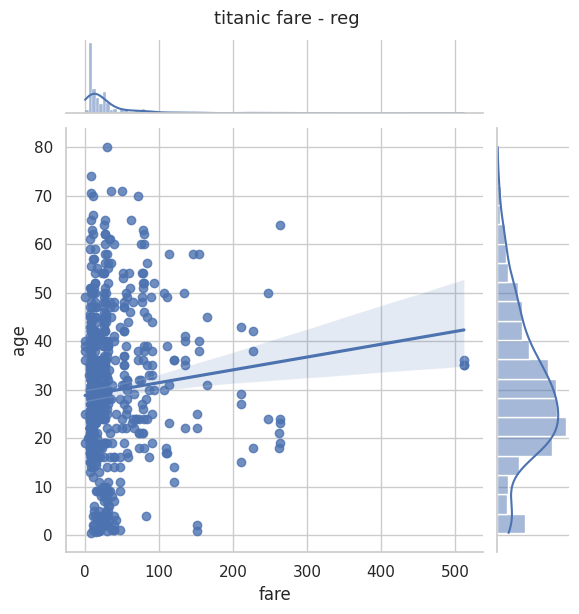

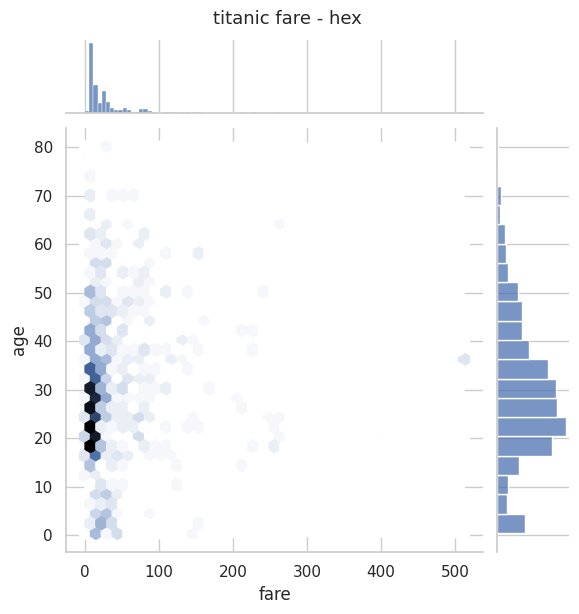

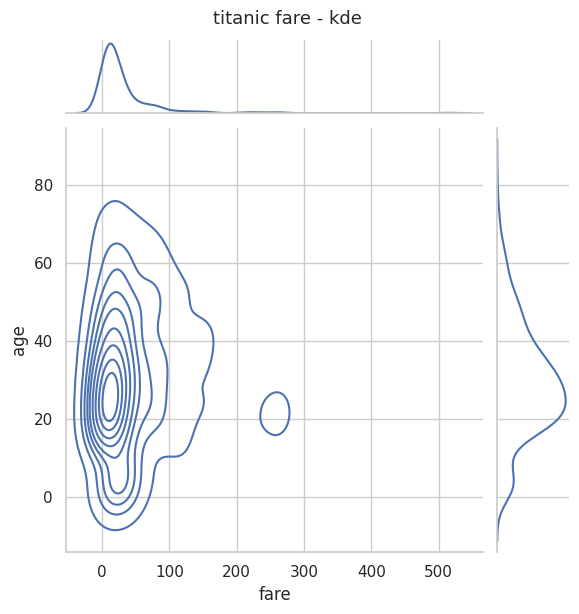

In [ ]:
# -*- coding: utf-8 -*-

import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')
sns.set_theme(style='whitegrid')

# j1 - 산점도
j1 = sns.jointplot(x='fare', y='age', data=titanic)
j1.fig.suptitle('titanic fare - scatter', size=13, y=1.02)
plt.show()

# j2 - 회귀선
j2 = sns.jointplot(x='fare', y='age', kind='reg', data=titanic)
j2.fig.suptitle('titanic fare - reg', size=13, y=1.02)
plt.show()

# j3 - 육각
j3 = sns.jointplot(x='fare', y='age', kind='hex', data=titanic)
j3.fig.suptitle('titanic fare - hex', size=13, y=1.02)
plt.show()

# j4 - 커널 밀도
j4 = sns.jointplot(x='fare', y='age', kind='kde', data=titanic)
j4.fig.suptitle('titanic fare - kde', size=13, y=1.02)
plt.show()

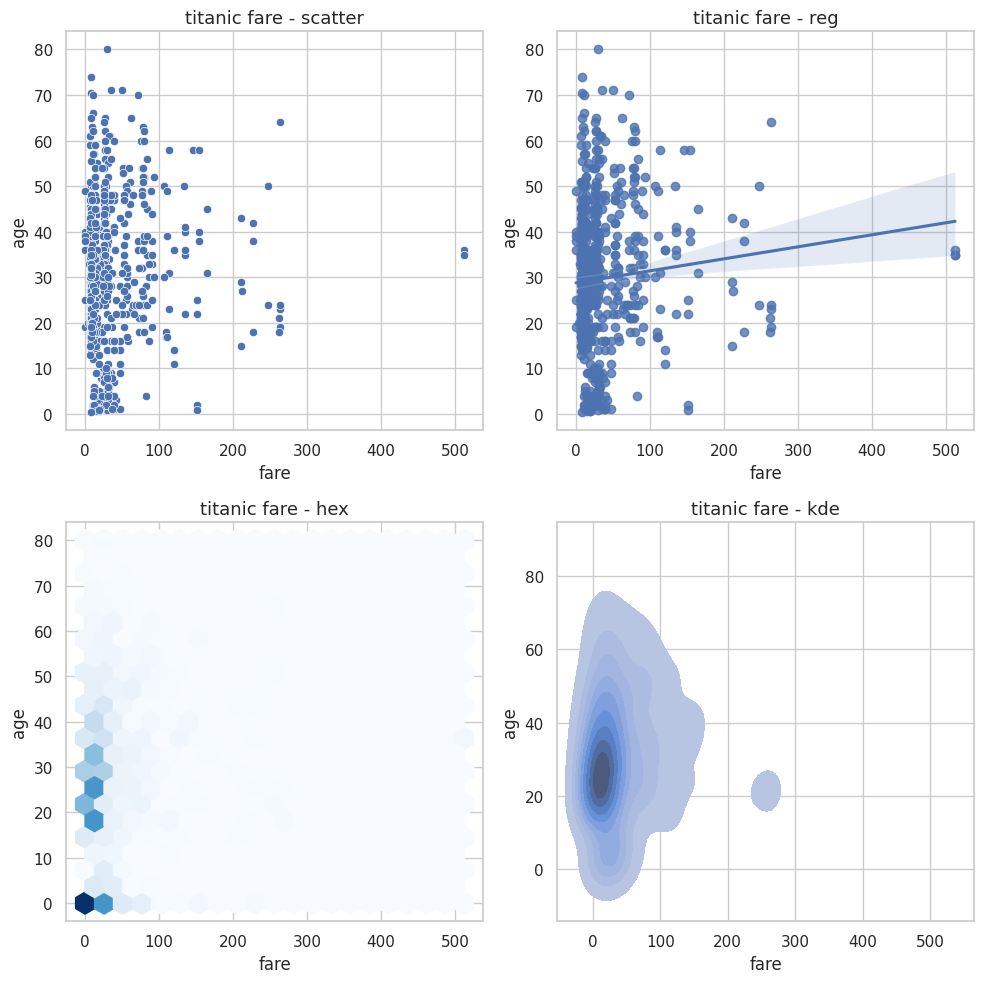

In [ ]:
# -*- coding: utf-8 -*-

import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드 및 스타일 설정
titanic = sns.load_dataset('titanic')
sns.set_theme(style='whitegrid')

# 2x2 서브플롯 틀 생성 (그래프 전체 크기 설정)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# --- j1: 산점도 (scatter) ---
# 메인 그래프
sns.scatterplot(x='fare', y='age', data=titanic, ax=axes[0, 0])
axes[0, 0].set_title('titanic fare - scatter', size=13)

# --- j2: 회귀선 (reg) ---
sns.regplot(x='fare', y='age', data=titanic, ax=axes[0, 1])
axes[0, 1].set_title('titanic fare - reg', size=13)

# --- j3: 육각 그래프 (hex) ---
# hexbin은 matplotlib의 기본 함수를 사용합니다.
axes[1, 0].hexbin(titanic['fare'].fillna(0), titanic['age'].fillna(0), gridsize=20, cmap='Blues')
axes[1, 0].set_xlabel('fare')
axes[1, 0].set_ylabel('age')
axes[1, 0].set_title('titanic fare - hex', size=13)

# --- j4: 커널 밀도 (kde) ---
sns.kdeplot(x='fare', y='age', data=titanic, ax=axes[1, 1], fill=True)
axes[1, 1].set_title('titanic fare - kde', size=13)

# 여백 자동 조절 후 출력
plt.tight_layout()
plt.show()

### 2-10 조건을 적용하여 화면을 그리드로 분할하기

**`sns.FacetGrid(data=데이터프레임, col="열방향분할열", row="행방향분할열")`**

- 지정한 열의 값 별로 행 방향과 열 방향으로 서브 플롯을 나눠서 만든 그리드 객체를 반화하는 함수

**`FacetGrid객체.map(그래프함수, "열이름")`**

- 그리드의 각 서브 플롯마다 해당 조건에 맞는 데이터만 골라서 지정한 그래프 함수로 지정한 열을 그리는 메소드

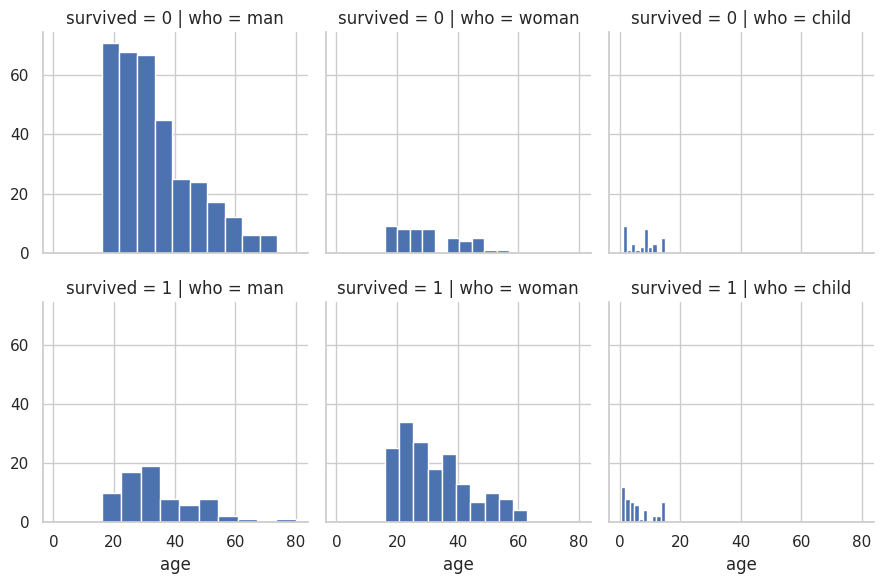

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정 (5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('whitegrid')

# 조건에 따라 그리드 나누기
g = sns.FacetGrid(data=titanic, col='who', row='survived')

# 그래프 적용하기
g = g.map(plt.hist, 'age')

### 2-11 이변수 데이터의 분포

- `sns.pairplot(데이터프레임)` : 전달된 DataFrame의 열을 두 개씩 짝 지을 수 있는 모든 조합에 대해 그래프를 그리는 함수
    - 같은 변수끼리 짝이 되는 대각선 칸에는 그 변수의 히스토그램을 그림
    - 서로 다른 변수끼리이면 두 변수의 산점도를 그림

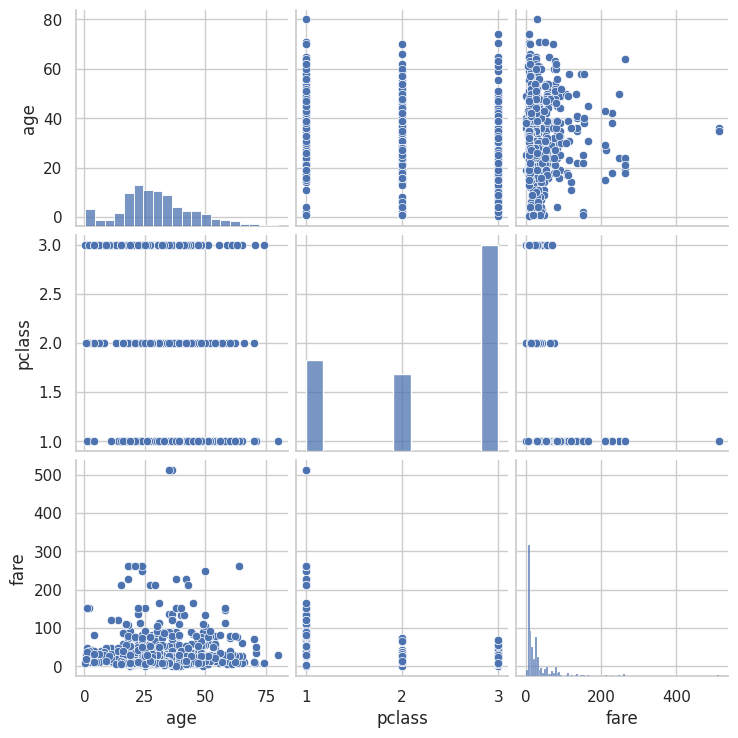

In [ ]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정 (5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('whitegrid')

# titanic 데이터셋 중에서 분석 데이터 선택하기
titanic_pair = titanic[['age', 'pclass', 'fare']]

# 조건에 따라 그리드 나누기
g = sns.pairplot(titanic_pair)

## 3. Folium 라이브러리

### 3-1 지도 만들기

- `folium.Map(location=[위도, 경도], zoom_start=숫자)` : 지도 객체를 만드는 함수
    - `location` : 지도 화면의 중심이 될 좌표를 [위도, 경도] 리스트로 지정
    - `zoom_start` : 처음 표시할 때 확대 비율
- `지도객체.save("저장할위치/파일이름.html")`: 지도 객체를 HTML 파일로 저장하는 메소드
- `folium.Map(location=[위도, 경도], tiles="타일주소/{z}/{y}/{x}", attr="출처표시문구", zoom_start=숫자)`
    - `tiles="타일주소템플릿"`: 지도 타일 이미지를 가져올 주소
        - `{z}`, `{y}`, `{x}` : 지도가 확대 수준과 위치에 따라 자동으로 채워 넣는 자리표시자
    - `attr="출처표시문구”` : 타일 제공처를 표시하는 문구
        - 이름으로 지정하는 내장 타일에서는 생략, 주소로 직접 지정하는 경우는 필수로 기재

In [6]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import folium

# 서울 지도 만들기
seoul_map = folium.Map(
    location=[37.55, 126.98],
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    zoom_start=12)

# 지도를 HTML 파일로 저장하기
seoul_map.save('./seoul.html')
seoul_map

### 3-2 지도 스타일 적용하기

- `Map()` 함수에 `tiles` 옵션 적용: 지도에 적용하는 스타일을 변경해 지정 가능

In [7]:
# -*- coding: utf-8 -*-

# 라이브러리 불러오기
import folium

# 서울 지도 만들기 (CartoDB 타일 사용으로 403 차단 회피)
seoul_map2 = folium.Map(location=[37.55, 126.98], tiles='Cartodb Positron',
                        zoom_start=12)
seoul_map3 = folium.Map(location=[37.55, 126.98], tiles='Cartodb Dark_Matter',
                        zoom_start=15)

# 지도를 HTML 파일로 저장하기
seoul_map2.save('./seoul2.html')
seoul_map3.save('./seoul3.html')

# 코랩 화면 출력
seoul_map2

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


### 3-3 지도에 마커 표시하기

- `zip(반복가능객체1, 반복가능객체2, ...)` : 여러 반복 가능한 객체에서 같은 위치의 원소끼리 묶어서 하나씩 꺼내주는 파이썬 내장 함수
- `folium.Marker([lat, lng], popup=str(name)).add_to(seoul_map)` : 지도에 위치를 표시하는 마커 객체를 만드는 함수
    - `Marker()` :지정한 좌표에 핀 모양 마커 객체를 만듦
    - `popup` : 마커를 클릭했을 때 표시되는 텍스트
    - `add_to(지도객체)` : 만든 마커를 지도 객체에 추가하는 메소드
- `folium.CircleMarker([위도, 경도], radius=숫자, color="테두리색", fill=True 또는 False, fill_color="채움색", fill_opacity=0~1, popup="텍스트")` : 원형 마커 객체를 만드는 함수
    - `radius` : 원의 반지름
    - `color` : 원의 테두리 색
    - `fill` : 원 내부를 채울지 여부
    - `fill_color` : 원 내부를 채우는 색
    - `fill_opacity` : 채움색의 투명도

In [11]:
# -*- coding: utf-8 -*-
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import folium

# 구글 드라이브 마운트 (최초 1회 인증 진행)
from google.colab import drive
drive.mount('/content/drive')

# Excel/CSV 데이터를 데이터프레임으로 변환
# 구글 시트 URL을 pandas가 바로 읽을 수 있는 CSV export 주소로 변환
file_path = 'https://docs.google.com/spreadsheets/d/1Vi5vT5xUWUW-9SeYvnRAaCzEjdvu24RJ/export?format=csv&gid=475171428'

# 데이터 불러오기 및 대학교명을 인덱스로 지정 (학교명/대학명이 1번째 열에 있는 경우)
df = pd.read_csv(file_path, index_col=0)

# 열 이름의 불필요한 공백 제거 (안전성 확보)
df.columns = df.columns.str.strip()

# 서울 지도 만들기
seoul_map = folium.Map(
    location=[37.55, 126.98],
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    zoom_start=12)

# 대학교 위치 정보를 Marker로 표시 (df['위도'], df['경도'] 사용 및 결측치 예방)
for name, lat, lng in zip(df.index, df['위도'], df['경도']):
    if pd.notna(lat) and pd.notna(lng):  # 위도, 경도 값이 존재하는 경우만 마커 생성
        folium.Marker([lat, lng], popup=str(name)).add_to(seoul_map)

# 지도를 HTML 파일로 저장하기
seoul_map.save('./seoul_colleges.html')

seoul_map

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# -*- coding: utf-8 -*-
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import folium

# 구글 드라이브 마운트 (최초 1회 인증 진행)
from google.colab import drive
drive.mount('/content/drive')

# Excel/CSV 데이터를 데이터프레임으로 변환
# 구글 시트 URL을 pandas가 바로 읽을 수 있는 CSV export 주소로 변환
file_path = 'https://docs.google.com/spreadsheets/d/1Vi5vT5xUWUW-9SeYvnRAaCzEjdvu24RJ/export?format=csv&gid=475171428'

# 데이터 불러오기 및 대학교명을 인덱스로 지정 (학교명/대학명이 1번째 열에 있는 경우)
df = pd.read_csv(file_path, index_col=0)

# 열 이름의 불필요한 공백 제거 (안전성 확보)
df.columns = df.columns.str.strip()

# 서울 지도 만들기
seoul_map = folium.Map(
    location=[37.55, 126.98],
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    zoom_start=12)

# 대학교 위치 정보를 Marker로 표시 (df['위도'], df['경도'] 사용 및 결측치 예방)
for name, lat, lng in zip(df.index, df['위도'], df['경도']):
    if pd.notna(lat) and pd.notna(lng):  # 위도, 경도 값이 존재하는 경우만 마커 생성
       folium.CircleMarker([lat, lng],
                        radius=10,            # 원의 반지름
                        color='brown',        # 원의 둘레 색상
                        fill=True,
                        fill_color='coral',   # 원을 채우는 색
                        fill_opacity=0.7,     # 투명도
                        popup=name
                        ).add_to(seoul_map)

# 지도를 HTML 파일로 저장하기
seoul_map.save('./seoul_colleges.html')

seoul_map

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 3-4 지도 영역에 단계구분도 표시하기

- `requests.get("주소")` : 지정한 웹 주소에 GET 요청을 보내고 서버의 응답을 담은 응답 객체를 반환하는 함수
- `응답객체.json()` : 응답 내용이 JSON 형식일 때 이를 파이썬 딕셔너리로 변환하는 메소드
- `folium.Choropleth(geo_data=경계정보, data=값데이터, columns=[키열, 값열], key_on="feature.properties.속성이름", fill_color="컬러맵", fill_opacity=0~1, line_opacity=0~1, threshold_scale=[구간경계값들])` : 단계구분도를 만드는 클래스
    - `key_on` : GeoJSON 안에서 `columns` 의 키 열 값과 대응시킬 속성 경로
    - `threshold_scale` : 값을 색상 단계로 나눌 구간의 경계값 리스트

In [18]:
# -*- coding: utf-8 -*-
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import folium
import json
import requests  # 구글 드라이브 URL의 GeoJSON을 읽어오기 위한 라이브러리

# 구글 드라이브 마운트 (최초 1회 인증 진행)
from google.colab import drive
drive.mount('/content/drive')

# Excel/CSV 데이터를 데이터프레임으로 변환
# 구글 시트 URL을 pandas가 바로 읽을 수 있는 CSV export 주소로 변환
file_path = 'https://docs.google.com/spreadsheets/d/1DBC5y3FoPPAQii1rw0ClV1Qant3dPdWs/export?format=csv&gid=335649750'

# 경기도 인구변화 데이터를 불러와서 데이터프레임으로 변환
df = pd.read_csv(file_path, index_col='구분')
df.columns = df.columns.map(str)

# 경기도 시군구 경계 정보를 가진 geo-json 파일 불러오기
# 구글 드라이브 공유 링크를 직접 다운로드 가능한 URL로 변환하여 json 불러오기
geo_url = 'https://drive.google.com/uc?id=1ztafRYWNkLfzT4qqBl0HN4Zn9nnoa-NC'
geo_data = requests.get(geo_url).json()

# 경기도 지도 만들기 (최신 타일 URL 및 필수 출처 attr 지정)
g_map = folium.Map(
    location=[37.5502, 126.982],
    tiles='https://tiles.stadiamaps.com/tiles/stamen_terrain/{z}/{x}/{y}{r}.png',
    attr='&copy; <a href="https://stadiamaps.com/">Stadia Maps</a> &copy; <a href="https://openmaptiles.org/">OpenMapTiles</a> &copy; <a href="https://openstreetmap.org">OpenStreetMap</a> contributors',
    zoom_start=9
)

# 출력할 연도 선택 (2007~2017년 중에서 선택)
year = '2007'

# Choropleth 클래스로 단계구분도 표시하기
folium.Choropleth(
    geo_data=geo_data,                                    # 지도 경계
    data=df[year],                                         # 표시하려는 데이터
    columns=[df.index, df[year]],                          # 열 지정
    fill_color='YlOrRd', fill_opacity=0.7, line_opacity=0.3,
    threshold_scale=[10000, 100000, 300000, 500000, 700000],
    key_on='feature.properties.name',
).add_to(g_map)

# 지도를 HTML 파일로 저장하기
g_map.save('./gyonggi_population_' + year + '.html')

g_map


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
